# Molecular Modeling of Materials PROJECT

Francesco Grassi (10841139) and Giorgio Venezia (1080030)

This project explores a machine learning-driven approach to modeling the molecular dynamics of a 64-Silicon bulk. We implement a custom Neural Network Potential (NNP) to predict potential energies and atomic force. The workflow is structured around the following key phases:

- **Data Generation:** we performed a LAMMPS simulation utilizing the Stillinger-Weber empirical potential to generate a diverse, multi-state dataset for a 64-atom Silicon system. The simulation spans six distinct thermodynamic phases: initial crystalline solid equilibration at 300 K, gradual heating to 1500 K, high-temperature solid maintenance, melting into a liquid state at 3000 K, rapid quenching back to 300 K, and final equilibration of the resulting amorphous phase.
- **Data Preparation & Feature Engineering:** We parse LAMMPS trajectory files containing 64 Silicon atoms and compute rotationally and translationally invariant Behler-Parrinello Symmetry Functions (G1 radial and G2 angular functions) to represent the local atomic environments.
- **Neural Network Training:** A PyTorch-based FeedForward Neural Network is trained to map these symmetry functions to the total potential energy of the system, utilizing learning rate scheduling and early stopping to prevent overfitting.
- **Force Evaluation:** Cartesian forces are analytically derived on-the-fly using PyTorch's automatic differentiation of our trained energy model.
- **Molecular Dynamics (MD):** Using the NNP-predicted forces, we run a custom Velocity Verlet integration loop to simulate the dynamics of the Silicon atoms initialized at a temperature of 300 K.
- **Physical Validation & Property Calculation:** To validate the physical accuracy of the simulated trajectory, we compute the Radial Distribution Function (RDF) and the Vibrational Density of States (VDOS). Furthermore, a Müller-Plathe reverse Non-Equilibrium Molecular Dynamics (NEMD) approach is applied to compute the thermal conductivity of the material.

This end-to-end pipeline demonstrates the viability of utilizing neural networks to replicate physical force fields and extract complex thermodynamic and structural properties of materials.

## ⚙️ **Libraries Import**

In [130]:
'''
Libraries required, uncomment and run only if needed
'''

# %pip install numpy pandas matplotlib seaborn scikit-learn scipy numba tqdm

# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# %pip install tensorboard torchsummary

# %pip install ase lammps

'\nLibraries required, uncomment and run only if needed\n'

In [131]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import random
import numpy as np
from datetime import datetime

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    torch.mps.manual_seed(SEED)
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
from scipy.fftpack import fft, fftfreq

logs_dir = "networks"

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

from ase.io import read

rng = np.random.default_rng(SEED)

PyTorch version: 2.7.1+cu118
Device: cuda


## 🐱 **Network Hyperparameters**

In [132]:
BATCH_SIZE = 128

HIDDEN_LAYERS = 2
HIDDEN_SIZE   = 64
DROPOUT_RATE = 0.0

LEARNING_RATE = 1e-4
EPOCHS = 1500
PATIENCE = 75
L2_LAMBDA = 0.0

N_RADIAL = 32
N_ANGULAR = 16

## ⚛️ Data Generation

We generated the dataset used for training the NNP by performing classical Molecular Dynamics (MD) simulations using LAMMPS. As our ground-truth baseline to compute target energies and forces, we utilized the Stillinger-Weber (SW) empirical potential for Silicon instead of DFT because SW is less computational demanding. A DFT approach would have required weeks of simulation.
The simulation models a bulk Silicon system containing **64** atoms. The system is initialized in a **crystalline diamond lattice structure** and simulated under **3D periodic boundary conditions** (PBC) to emulate an infinite bulk material.

![Silicon Bulk Supercell](silicon_bulk.png)

To ensure the neural network can predict values from a wide variety of atomic environments (from ordered crystal lattices to disordered liquids), our LAMMPS script drives the system through six distinct thermodynamic phases using an NVT ensemble (constant Number of atoms, Volume, and Temperature):
- **Crystalline Equilibration (300 K):** The solid is stabilized at room temperature to gather standard baseline configurations.
- **Heating (300 K $\rightarrow$ 1500 K):** The system undergoes thermal expansion as the temperature is steadily increased.
- **High-Temperature Solid (1500 K):** The solid state is maintained at high temperatures to capture strong lattice vibrations and anharmonic effects.
- **Melting & Liquid Phase (3000 K):** The temperature is pushed well above the melting point, creating a chaotic liquid state characterized by frequent bond breaking.
- **Quenching (3000 K $\rightarrow$ 300 K):** An instantaneous cooling process freezes the disordered liquid structure, inducing a liquid-to-amorphous transition.
- **Amorphous Equilibration (300 K):** The resulting amorphous phase is stabilized at room temperature to collect data on stable non-crystalline structures.

Throughout the simulation, the system's state is captured at regular time intervals (every 1000 steps). The resulting output file logs the atomic IDs, Cartesian coordinates $(x,y,z)$, analytical force components $(f_x, f_y, f_z)$, and the individual potential energy for every atom.

_Note: The full LAMMPS script used to run this simulation is in si.lmp, together with his dump, so it's not needed to rerun it._

## ⏳ **Data Loading**

In [133]:
def parse_lammps_dump_to_csv(filepath, output_csv):
    """
    Parses a LAMMPS trajectory dump file and extracts atomic data into a structured CSV format.

    This function reads the output dump file sequentially, extracting the timestep, 
    calculating the simulation box dimensions from the boundary data, and retrieving 
    per-atom properties. It is specifically tailored to map the custom LAMMPS dump 
    format to a tabular dataset containing coordinates, forces, and potential energies.

    Parameters:
        filepath (str): The file path to the input LAMMPS `.dump` file.
        output_csv (str): The file path where the extracted data will be saved as a `.csv`.

    Returns:
        None: The function does not return an object, but writes directly to the output file.
    """
    print(f"Extracting {filepath} to {output_csv}...")
    with open(output_csv, 'w') as out_f:
        header = "timestep,box_x,box_y,box_z,atom_id,x,y,z,fx,fy,fz,pe_atom\n"
        out_f.write(header)
        with open(filepath, 'r') as f:
            while True:
                line = f.readline()
                if not line:
                    break
                if "ITEM: TIMESTEP" in line:
                    timestep = f.readline().strip()
                elif "ITEM: NUMBER OF ATOMS" in line:
                    n_atoms = int(f.readline().strip())
                elif "ITEM: BOX BOUNDS" in line:
                    box_x_data = f.readline().split()
                    box_y_data = f.readline().split()
                    box_z_data = f.readline().split()
                    box_x = f"{float(box_x_data[1]) - float(box_x_data[0]):.4f}"
                    box_y = f"{float(box_y_data[1]) - float(box_y_data[0]):.4f}"
                    box_z = f"{float(box_z_data[1]) - float(box_z_data[0]):.4f}"
                elif "ITEM: ATOMS" in line:
                    for _ in range(n_atoms):
                        data = f.readline().split()
                        atom_id = data[0]
                        x, y, z = data[2], data[3], data[4]
                        fx, fy, fz = data[5], data[6], data[7]
                        pe_atom = data[8]
                        row = f"{timestep},{box_x},{box_y},{box_z},{atom_id},{x},{y},{z},{fx},{fy},{fz},{pe_atom}\n"
                        out_f.write(row)
    print("Done")

In [134]:
'''
If the symmetry dataset is not found, the code will attempt to parse the corresponding LAMMPS dump file and extract it to a CSV format.
The paths for the symmetry dataset and the extracted data are defined, and the code checks for their existence.

If the symmetry dataset exists, it will be used; otherwise, the extracted data will be used.
The data is then read into a pandas DataFrame for further processing.
'''

symmetry_dataset_path = f'lammps/silicon_symmetry_dataset_64_forces.csv'
extracted_data_path = 'lammps/dataset64.csv'
if not os.path.exists(extracted_data_path):
    try:
        # try to find the correspective .dump file and extract it to .csv
        parse_lammps_dump_to_csv(extracted_data_path[:-4] + '.dump', extracted_data_path)
    except Exception as e:
        print(f"Error occurred while parsing LAMMPS dump file: {e}")

generate = True

# Set file_path based on existence of the symmetry dataset
if os.path.exists(symmetry_dataset_path):
    file_path = symmetry_dataset_path
    generate = False
    print(f"Using augmented dataset: {file_path}")
else:
    file_path = extracted_data_path
    print(f"Augmented dataset not found. Using original data: {file_path}")

data = pd.read_csv(file_path, engine='pyarrow')

display(data.head())

Using augmented dataset: lammps/silicon_symmetry_dataset_64_forces.csv


,timestep,box_x,box_y,box_z,atom_id,x,y,z,fx,fy,...,g2_30,g2_31,g2_32,g2_33,g2_34,g2_35,g2_36,g2_37,g2_38,g2_39
0,0,10.862,10.862,10.862,1,0.00000,0.00000,0.00000,4.235760e-15,4.235740e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,10.862,10.862,10.862,2,2.71550,2.71550,0.00000,-4.790280e-16,-4.790280e-16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,10.862,10.862,10.862,3,1.35775,1.35775,1.35775,-2.710510e-20,-2.710510e-20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,10.862,10.862,10.862,4,4.07325,4.07325,1.35775,3.174820e-15,3.174810e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,10.862,10.862,10.862,5,0.00000,2.71550,2.71550,7.345740e-15,-4.311600e-16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 🔎 **Exploration and Data Analysis**

In [135]:
silicon_dataset = data
print('Silicon dataset shape:', silicon_dataset.shape)

silicon_dataset.head(10)

Silicon dataset shape: (576064, 84)


,timestep,box_x,box_y,box_z,atom_id,x,y,z,fx,fy,...,g2_30,g2_31,g2_32,g2_33,g2_34,g2_35,g2_36,g2_37,g2_38,g2_39
0,0,10.862,10.862,10.862,1,0.00000,0.00000,0.00000,4.235760e-15,4.235740e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,10.862,10.862,10.862,2,2.71550,2.71550,0.00000,-4.790280e-16,-4.790280e-16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,10.862,10.862,10.862,3,1.35775,1.35775,1.35775,-2.710510e-20,-2.710510e-20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,10.862,10.862,10.862,4,4.07325,4.07325,1.35775,3.174820e-15,3.174810e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,10.862,10.862,10.862,5,0.00000,2.71550,2.71550,7.345740e-15,-4.311600e-16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0,10.862,10.862,10.862,6,2.71550,0.00000,2.71550,-4.311600e-16,7.345710e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0,10.862,10.862,10.862,7,1.35775,4.07325,4.07325,-2.144930e-15,3.174760e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0,10.862,10.862,10.862,8,4.07325,1.35775,4.07325,3.174760e-15,-2.144930e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0,10.862,10.862,10.862,9,0.00000,0.00000,5.43100,6.428560e-15,6.428530e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0,10.862,10.862,10.862,10,2.71550,2.71550,5.43100,-2.671800e-15,-2.671800e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


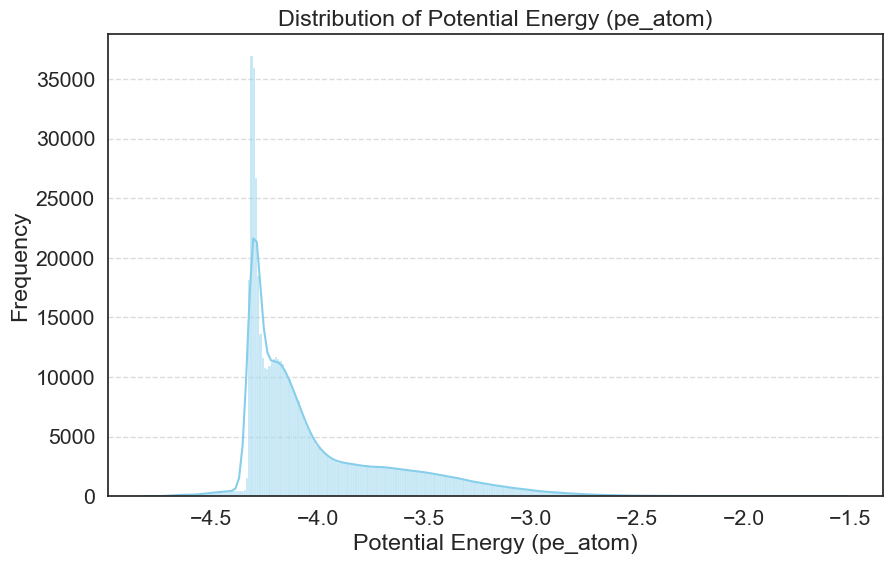

In [136]:
plt.figure(figsize=(10, 6))
sns.histplot(silicon_dataset['pe_atom'], kde=True, color='skyblue')
plt.title('Distribution of Potential Energy (pe_atom)')
plt.xlabel('Potential Energy (pe_atom)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [137]:
# Check for missing values in each column
missing_values = silicon_dataset.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
timestep    0
box_x       0
box_y       0
box_z       0
atom_id     0
           ..
g2_35       0
g2_36       0
g2_37       0
g2_38       0
g2_39       0
Length: 84, dtype: int64


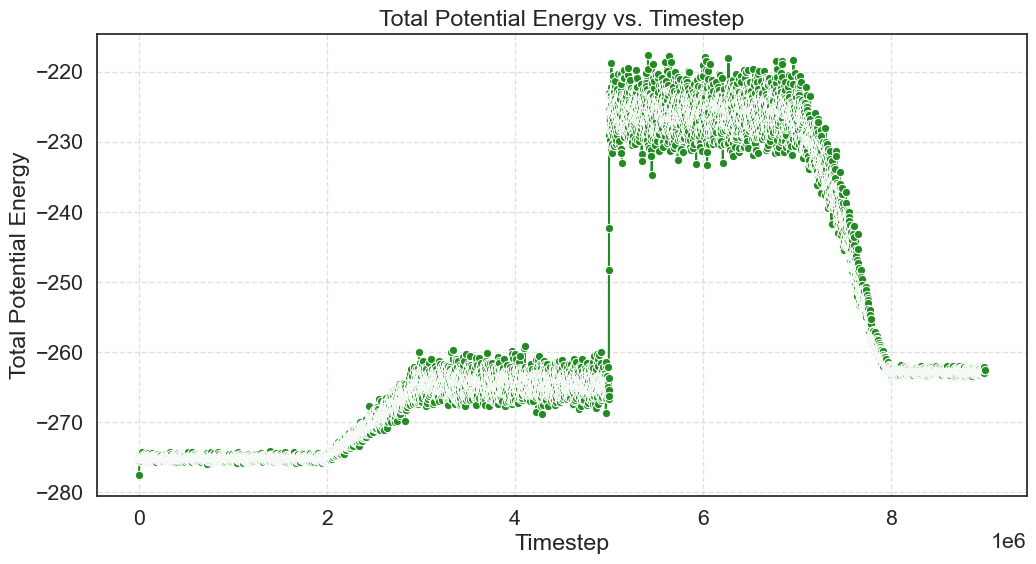

In [138]:
# Group by timestep and sum the potential energy of all atoms to get total energy
total_energy_per_step = silicon_dataset.groupby('timestep')['pe_atom'].sum().reset_index()

# Plot Total Energy vs Timestep
plt.figure(figsize=(12, 6))
sns.lineplot(data=total_energy_per_step, x='timestep', y='pe_atom', marker='o', color='forestgreen')
plt.title('Total Potential Energy vs. Timestep')
plt.xlabel('Timestep')
plt.ylabel('Total Potential Energy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 🔀 **Converting Function**
Raw Cartesian coordinates $(x, y, z)$ are fundamentally unsuited as direct inputs for neural networks designed to predict potential energy. This is because the potential energy of an isolated molecular system or bulk material must strictly adhere to three physical invariances:
- **Translational Invariance:** Shifting the entire system in space does not alter its total energy.
- **Rotational Invariance:** Rotating the entire system does not alter its total energy.
- **Permutational Invariance:** Swapping the internal indices of two identical atoms (e.g., two Silicon atoms) does not change the physical state or the energy of the system.

If a neural network were fed raw coordinates, it would have to expend significant learning capacity simply to "memorize" these basic physical laws. To solve this, Behler and Parrinello in their article (DOI: [10.1103/PhysRevLett.98.146401](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.98.146401)) introduced **Symmetry Functions**, a new set of mathematical transformations that map the 3D Cartesian coordinates into a high-dimensional feature space that intrinsically guarantees all three invariances.

Symmetry functions construct a structural "fingerprint" describing the local atomic environment around a central atom $i$ within a specific cutoff radius $R_c$.

To ensure that atoms entering or leaving this local environment do not cause discontinuous jumps in the predicted energy, a continuous cutoff function $f_c(R_{ij})$ is applied, which smoothly decays to zero at the boundary: 

$f_c(R_{ij}) = \begin{cases} 0.5 \left( \cos\left(\frac{\pi R_{ij}}{R_c}\right) + 1 \right) & \text{for } R_{ij} \le R_c \\ 0 & \text{for } R_{ij} > R_c \end{cases}$

Using this cutoff function, we compute two primary types of symmetry functions to describe the environment:

1. **Radial Symmetry Functions ($G^1$):** These functions capture the distance distribution of neighboring atoms around the central atom $i$. By varying the width $\eta$ and the shift parameter $R_s$, we can probe different concentric radial shells to build a complete distance profile:

    $G_i^1 = \sum_{j \neq i} e^{-\eta (R_{ij} - R_s)^2} f_c(R_{ij})$

2. **Angular Symmetry Functions ($G^2$):** While radial functions capture distances, they cannot distinguish between different geometric arrangements of neighbors at the same distance. Angular functions solve this by evaluating the angles $\theta_{ijk}$ formed by triplets of atoms (the central atom $i$ and two neighbors $j$ and $k$).  The parameters $\lambda \in \{-1, 1\}$ and $\zeta$ dictate the angular alignment and the sharpness of the angular resolution, respectively:
    
    $G_i^2 = 2^{1-\zeta} \sum_{j \neq i} \sum_{k \neq i,j} (1 + \lambda \cos\theta_{ijk})^\zeta \cdot e^{-\eta (R_{ij}^2 + R_{ik}^2 + R_{jk}^2)} f_c(R_{ij}) f_c(R_{ik}) f_c(R_{jk})$
    
By generating a grid of these functions with varying parameters, we create a robust, invariant feature vector for every atom, which the neural network can then efficiently map to individual atomic energy contributions.

In [139]:
def compute_symmetry_functions_vectorized(coords_3d, Rc, eta_rad, Rs, eta_ang, zeta, lmbda, pbc=False, box_lengths=None):
    """
    Computes G1 and G2 symmetry functions for each atom in each frame.

    Parameters:
    - coords_3d:    (num_frames, num_atoms, 3) array of coordinates.
    - box_lengths:  (3,) array containing the dimensions of the simulation box (Lx, Ly, Lz).
                    Must be passed as an array even if pbc=False (e.g., np.zeros(3)).
    - eta_rad:      1-D array of eta values for radial (G1) functions.
    - eta_ang:      1-D array of eta values for angular (G2) functions.
    - Rc:           cutoff radius.
    - Rs:           1-D array of radial shift values.
    - lmbda:        1-D array of lambda values for angular functions.
    - zeta:         1-D array of zeta values for angular functions.
    - pbc:          Boolean flag to enable/disable Periodic Boundary Conditions.
    """
    B, N, _ = coords_3d.shape
    device = coords_3d.device
    dtype = coords_3d.dtype

    # 1. Calculate all distance vectors in one go (B, N, N, 3)
    diff = coords_3d.unsqueeze(2) - coords_3d.unsqueeze(1)

    if pbc and box_lengths is not None:
        box = box_lengths.view(1, 1, 1, 3)
        diff = diff - box * torch.round(diff / box)

    # Distance matrix (B, N, N)
    dist = torch.norm(diff, dim=-1)

    # 2. Cutoff function and Mask
    fc = 0.5 * (torch.cos(torch.pi * dist / Rc) + 1.0)
    
    # Mask to exclude the atoms themselves (diagonal) and distances > Rc
    eye = torch.eye(N, dtype=torch.bool, device=device).unsqueeze(0) # (1, N, N)
    valid_ij = (dist <= Rc) & (~eye)
    fc = torch.where(valid_ij, fc, torch.zeros_like(fc))

    # 3. Radial functions G1
    eta_r = eta_rad.view(1, 1, 1, -1)
    Rs_v  = Rs.view(1, 1, 1, -1)
    dist_exp = dist.unsqueeze(-1) 
    fc_exp   = fc.unsqueeze(-1)     

    g1_terms = torch.exp(-eta_r * (dist_exp - Rs_v)**2) * fc_exp
    G1 = g1_terms.sum(dim=2) # Sum over j -> Result: (B, N, num_rad)

    # 4. Angular functions G2
    # Create a flat grid of all angular parameters to compute them in parallel
    grid_ea, grid_z, grid_l = torch.meshgrid(eta_ang, zeta, lmbda, indexing='ij')
    ea_flat = grid_ea.flatten().view(1, 1, 1, 1, -1)
    z_flat  = grid_z.flatten().view(1, 1, 1, 1, -1)
    l_flat  = grid_l.flatten().view(1, 1, 1, 1, -1)

    # Prepare the distances for the triplet i, j, k
    R_ij = dist.unsqueeze(3) # (B, N, N, 1)
    R_ik = dist.unsqueeze(2) # (B, N, 1, N)
    R_jk = dist.unsqueeze(1) # (B, 1, N, N)

    fc_ij = fc.unsqueeze(3)
    fc_ik = fc.unsqueeze(2)
    fc_jk = fc.unsqueeze(1)

    # Mask for valid triplets (j!=i, k!=i, j!=k and all under Rc)
    valid_ik = valid_ij.unsqueeze(2) 
    valid_jk = valid_ij.unsqueeze(1) 
    j_neq_k  = ~torch.eye(N, dtype=torch.bool, device=device).view(1, 1, N, N)
    valid_ijk = valid_ij.unsqueeze(3) & valid_ik & valid_jk & j_neq_k

    # Calculate the angle (cos theta)
    vec_ij = diff.unsqueeze(3) 
    vec_ik = diff.unsqueeze(2) 
    dot = torch.sum(vec_ij * vec_ik, dim=-1) # Dot product
    cos_theta = dot / (R_ij * R_ik + 1e-8)   # Avoid division by zero

    # Calculate the Behler-Parrinello terms
    exp_arg = R_ij**2 + R_ik**2 + R_jk**2 
    exp_term = torch.exp(-ea_flat * exp_arg.unsqueeze(-1)) 
    cos_term = (1.0 + l_flat * cos_theta.unsqueeze(-1))**z_flat

    ang_terms = (2.0**(1.0 - z_flat)) * cos_term * exp_term
    ang_terms = ang_terms * (fc_ij * fc_ik * fc_jk).unsqueeze(-1) # Apply cutoffs

    # Zero out spurious terms not included in the mask
    ang_terms = torch.where(valid_ijk.unsqueeze(-1), ang_terms, torch.zeros_like(ang_terms))

    # Sum over j and k
    G2 = ang_terms.sum(dim=(2, 3)) # Result: (B, N, num_ang)

    # 5. Final concatenation
    return torch.cat([G1, G2], dim=-1)

There are several techniques to automatize the construction of the symmetry functions. We extract four of them from these two articles: [[DOI: 10.1063/1.5019667]](https://doi.org/10.1063/1.5019667) and [[DOI: 10.1063/1.5024611]](https://doi.org/10.1063/1.5024611):

* **Imbalzano Centered Rule:** This strategy focuses on Gaussians centered at the origin ($R_s = 0$) with exponentially spaced widths ($\eta_m=\frac{n^{m/n}}{R_c}$).


* **Imbalzano Shifted Rule:** In this approach, Gaussians are shifted along $R_s$ on a logarithmic grid. The $\eta$ parameter is computed dynamically to ensure optimal overlap between adjacent shells as $\frac{1}{(R_{s_{i}} - R_{s_{i+1}})^2}$


* **Gastegger Centered Rule:** Gaussians are centered at $R_s = 0$, but their widths ($\eta$) decrease quadratically ($1/r^2$, $r \in [R_{lower}, R_{upper}]$) to provide higher resolution closer to the reference atom.


* **Gastegger Shifted Rule:** Gaussians are shifted along $R_s$ on a linear grid. The width parameter ($\eta=\frac{1}{(2 \Delta r)^2}$, with $\Delta r = \frac{R_{upper}-R_{lower}}{N_{Radial} - 1}$) is kept constant to ensure smooth resolution across the radial space. This is the active strategy selected for the calculation of our symmetry functions.

In [140]:
def get_imbalzano_centered_params(N_RADIAL, N_ANGULAR, Rc_val):
    """
    Imbalzano Centered Rule
    Focus: Gaussians centered at Rs=0 with exponentially spaced widths (eta).
    """
    indices_radial = np.array(range(0, N_RADIAL))
    indices_angular = np.array(range(0, N_ANGULAR // 2))
    
    Rs_grid = np.zeros(N_RADIAL)
    eta_radial = ((N_RADIAL - 1) ** (indices_radial / (N_RADIAL - 1)) / Rc_val) ** 2
    
    eta_angular = (((N_ANGULAR // 2) - 1) ** (indices_angular / ((N_ANGULAR // 2) - 1)) / Rc_val) ** 2
    lambda_grid = np.array([-1.0, 1.0])
    zeta_grid = np.array([1.0, 4.0, 16.0])
    
    return eta_radial, Rs_grid, eta_angular, lambda_grid, zeta_grid


def get_imbalzano_shifted_params(N_RADIAL, N_ANGULAR, Rc_val):
    """
    Imbalzano Shifted Rule
    Focus: Gaussians shifted along Rs on a logarithmic grid; eta is computed dynamically.
    """
    indices_radial = np.array(range(0, N_RADIAL))
    indices_angular = np.array(range(0, N_ANGULAR // 2))
    
    Rs_grid = Rc_val / N_RADIAL ** (indices_radial / N_RADIAL)
    eta_radial = np.zeros(N_RADIAL)
    for i in range(len(Rs_grid) - 1):
        eta_radial[i] = 1.0 / (Rs_grid[i] - Rs_grid[i + 1]) ** 2
        
    # Reverse grids to start from the closest shell to the furthest
    Rs_grid = np.flip(Rs_grid[1:])
    eta_radial = np.flip(eta_radial)
    
    # Applying the standard Imbalzano angular settings for consistency
    eta_angular = (((N_ANGULAR // 2) - 1) ** (indices_angular / ((N_ANGULAR // 2) - 1)) / Rc_val) ** 2
    lambda_grid = np.array([-1.0, 1.0])
    zeta_grid = np.array([1.0, 4.0, 16.0])
    
    return eta_radial, Rs_grid, eta_angular, lambda_grid, zeta_grid


def get_gastegger_centered_params(N_RADIAL, r_low=2.0, r_upp=3.5):
    """
    Gastegger Centered Rule
    Focus: Gaussians centered at Rs=0. Widths (eta) decrease quadratically (1/r^2).
    """
    grid_radial = np.linspace(r_low, r_upp, N_RADIAL)
    
    Rs_grid = np.zeros(N_RADIAL)
    eta_radial = 1.0 / (grid_radial ** 2)
    
    # Shared Angular settings for Gastegger representation
    eta_angular = np.array([0.001, 0.01, 0.05, 0.1])
    lambda_grid = np.array([-1.0, 1.0])
    zeta_grid = np.array([1.0, 2.0, 4.0, 8.0, 16.0])
    
    return eta_radial, Rs_grid, eta_angular, lambda_grid, zeta_grid


def get_gastegger_shifted_params(N_RADIAL, r_low=2.0, r_upp=3.5):
    """
    Gastegger Shifted Rule
    Focus: Gaussians shifted along Rs on a linear grid. Eta is kept constant.
    """
    grid_radial = np.linspace(r_low, r_upp, N_RADIAL)
    dr_radial = (r_upp - r_low) / (N_RADIAL - 1)

    Rs_grid = grid_radial
    eta_radial = np.full(N_RADIAL, 1.0 / (2.0 * dr_radial**2))
    
    # Shared Angular settings for Gastegger representation
    eta_angular = np.array([0.001, 0.01, 0.05, 0.1])
    lambda_grid = np.array([-1.0, 1.0])
    zeta_grid = np.array([1.0, 2.0, 4.0, 8.0, 16.0])
    
    return eta_radial, Rs_grid, eta_angular, lambda_grid, zeta_grid

In [141]:
if generate == True:
    Rc_val = 3.7712  # The exact SW cutoff for Silicon
    
    eta_radial, Rs_grid, eta_angular, lambda_grid, zeta_grid = get_gastegger_shifted_params(
        N_RADIAL=N_RADIAL, 
        r_low=2.0, 
        r_upp=3.5
    )

    atoms_per_frame = len(np.unique(silicon_dataset['atom_id']))
    coords_flat = silicon_dataset[['x', 'y', 'z']].values
    coords_3d = coords_flat.reshape(-1, atoms_per_frame, 3)
    n_frames = coords_3d.shape[0]

    num_radial  = len(eta_radial) #* len(Rs_grid)
    num_angular = len(eta_angular) * len(zeta_grid) * len(lambda_grid)
    num_sf      = num_radial + num_angular

    print(f"Found {n_frames} frames of {atoms_per_frame} atoms each.")
    print(f"Symmetry functions: {num_radial} radial + {num_angular} angular = {num_sf} total")

    eta_radial_t  = torch.tensor(eta_radial, dtype=torch.float32, device=device)
    Rs_grid_t     = torch.tensor(Rs_grid, dtype=torch.float32, device=device)
    eta_angular_t = torch.tensor(eta_angular, dtype=torch.float32, device=device)
    zeta_grid_t   = torch.tensor(zeta_grid, dtype=torch.float32, device=device)
    lambda_grid_t = torch.tensor(lambda_grid, dtype=torch.float32, device=device)
    
    box_lengths = np.array([
        silicon_dataset['box_x'].iloc[0],
        silicon_dataset['box_y'].iloc[0],
        silicon_dataset['box_z'].iloc[0]
    ])
    box_lengths_t = torch.tensor(box_lengths, dtype=torch.float32, device=device)

    batch_size = 2 
    risultati_list = []

    for i in tqdm(range(0, n_frames, batch_size), desc="Computing symmetry functions (Vectorized)"):
        # Estraiamo il batch e lo carichiamo sul device con requires_grad=True
        batch_coords = coords_3d[i : i + batch_size]
        batch_coords_tensor = torch.tensor(batch_coords, dtype=torch.float32, device=device)
        batch_coords_tensor.requires_grad_(True)

        # Chiamiamo la nuova funzione ultra-veloce passandole I TENSORI
        batch_res = compute_symmetry_functions_vectorized(
            coords_3d=batch_coords_tensor,
            Rc=Rc_val,
            eta_rad=eta_radial_t,
            Rs=Rs_grid_t,
            eta_ang=eta_angular_t,
            zeta=zeta_grid_t,
            lmbda=lambda_grid_t,
            pbc=True,
            box_lengths=box_lengths_t
        )
        
        # Per poterli mettere in un DataFrame Pandas dopo, stacchiamo i risultati dal grafo
        risultati_list.append(batch_res.detach().cpu().numpy())
        
        if device == torch.device("cuda"):
            torch.cuda.empty_cache()
        elif device == torch.device("mps"):
            torch.mps.empty_cache()

    risultati_3d = np.vstack(risultati_list)
    print("Computation completed! Formatting the dataframe...")

    num_symmetry_functions = risultati_3d.shape[2]
    symmetry_flat = risultati_3d.reshape(-1, num_symmetry_functions)

    symmetry_cols = [f'sf_{i}' for i in range(num_symmetry_functions)]
    symmetry_df   = pd.DataFrame(symmetry_flat, columns=symmetry_cols)

    g1_cols = symmetry_cols[:num_radial]
    g2_cols = symmetry_cols[num_radial:]
    g1_df   = symmetry_df[g1_cols].copy()
    g2_df   = symmetry_df[g2_cols].copy()
    g1_df.columns = [f'g1_{i}' for i in range(len(g1_df.columns))]
    g2_df.columns = [f'g2_{i}' for i in range(len(g2_df.columns))]

    silicon_dataset = pd.concat([silicon_dataset.reset_index(drop=True), g1_df, g2_df], axis=1)

    print(f"Symmetry functions added! G1:{g1_df.shape[1]} G2:{g2_df.shape[1]} Dataset shape: {silicon_dataset.shape}")
    silicon_dataset.to_csv(symmetry_dataset_path, index=False)
    print(f"Saved to {symmetry_dataset_path}")

## 🔄 **Data Preprocessing**

In [142]:
n_atoms_per_frame = len(np.unique(silicon_dataset['atom_id']))
symmetry_cols = [c for c in silicon_dataset.columns if c.startswith('g1_') or c.startswith('g2_')]

print("=== DATASET DIAGNOSTICS ===")
print(f"Frames totali: {silicon_dataset['timestep'].nunique()}")
print(f"Atomi per frame: {n_atoms_per_frame}")
print(f"Features: {len(symmetry_cols)} symmetry functions")
print(f"\npe_atom statistics:")
print(silicon_dataset['pe_atom'].describe())
print(f"\nRange pe_atom: {silicon_dataset['pe_atom'].max() - silicon_dataset['pe_atom'].min():.4f} eV")

# Check symmetry functions are not all zero or degenerate
sf_cols = [c for c in silicon_dataset.columns if c.startswith('g1_') or c.startswith('g2_')]
sf_data = silicon_dataset[sf_cols]
print(f"\nSymmetry function statistics:")
std_threshold = 1e-10
low_std_cols = silicon_dataset[symmetry_cols].std().loc[lambda s: s < std_threshold].index.tolist()

print(f"Columns with zero variance: {(sf_data.std() < 1e-10).sum()}, {low_std_cols}")
print(f"Columns with NaN: {sf_data.isna().sum().sum()}")
print(f"Mean of all SF values: {sf_data.values.mean():.4f}")
print(f"Std of all SF values:  {sf_data.values.std():.4f}")

=== DATASET DIAGNOSTICS ===
Frames totali: 9001
Atomi per frame: 64
Features: 72 symmetry functions

pe_atom statistics:
count    576064.000000
mean         -4.004276
std           0.359242
min          -4.817480
25%          -4.275050
50%          -4.142860
75%          -3.838490
max          -1.510620
Name: pe_atom, dtype: float64

Range pe_atom: 3.3069 eV

Symmetry function statistics:
Columns with zero variance: 0, []
Columns with NaN: 0
Mean of all SF values: 0.0454
Std of all SF values:  0.1378


In [143]:
n_atoms = np.unique(silicon_dataset['atom_id']).size

silicon_dataset['frame_id'] = np.repeat(np.arange(len(silicon_dataset) // n_atoms), n_atoms)

# 1. Get unique frame_ids and split them
all_frames = silicon_dataset['frame_id'].unique()
train_frames, temp_frames = train_test_split(all_frames, test_size=0.10, random_state=SEED)
val_frames, test_frames = train_test_split(temp_frames, test_size=0.50, random_state=SEED)

# 2. Filter dataset and strictly sort to guarantee X and y alignment
train_df = silicon_dataset[silicon_dataset['frame_id'].isin(train_frames)].sort_values(['frame_id', 'atom_id'])
val_df = silicon_dataset[silicon_dataset['frame_id'].isin(val_frames)].sort_values(['frame_id', 'atom_id'])
test_df = silicon_dataset[silicon_dataset['frame_id'].isin(test_frames)].sort_values(['frame_id', 'atom_id'])

features_start_idx = silicon_dataset.columns.get_loc('g1_0')

# 3. Extract flattened X features for scaling
X_train_flat = train_df.iloc[:, features_start_idx:].values
X_val_flat = val_df.iloc[:, features_start_idx:].values
X_test_flat = test_df.iloc[:, features_start_idx:].values

# 4. Extract total energies per frame for y (Group by the unique frame_id!)
y_train_total = train_df.groupby('frame_id')['pe_atom'].sum().values
y_val_total = val_df.groupby('frame_id')['pe_atom'].sum().values
y_test_total = test_df.groupby('frame_id')['pe_atom'].sum().values

# 5. Scale features using the flattened arrays
feature_scaler = StandardScaler()
X_train_scaled_flat = feature_scaler.fit_transform(X_train_flat)
X_val_scaled_flat = feature_scaler.transform(X_val_flat)
X_test_scaled_flat = feature_scaler.transform(X_test_flat)

num_features = X_train_flat.shape[1]

# 6. RESHAPE X INTO 3D TENSORS: (num_frames, atoms_per_frame, num_features)
X_train_scaled = X_train_scaled_flat.reshape(-1, n_atoms, num_features)
X_val_scaled = X_val_scaled_flat.reshape(-1, n_atoms, num_features)
X_test_scaled = X_test_scaled_flat.reshape(-1, n_atoms, num_features)

# 7. Shift total target energies around 0, NNP works better with normalized features
mean_total_energy = y_train_total.mean()
y_train_shifted = y_train_total - mean_total_energy
y_val_shifted = y_val_total - mean_total_energy
y_test_shifted = y_test_total - mean_total_energy

print(f"Shapes for PyTorch -> X_train: {X_train_scaled.shape}, y_train: {y_train_shifted.shape}")
print(f"Shifted target energies by {mean_total_energy:.4f} eV")

Shapes for PyTorch -> X_train: (8100, 64, 73), y_train: (8100,)
Shifted target energies by -256.3131 eV


In [144]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels) and push them directly to the GPU
def to_device_if_cuda(tensor, device):
    return tensor.to(device) if device.type == 'cuda' else tensor

train_ds = TensorDataset (
    to_device_if_cuda(torch.from_numpy(X_train_scaled).float(), device),
    to_device_if_cuda(torch.from_numpy(y_train_shifted).float().unsqueeze(1), device)
)
val_ds = TensorDataset (
    to_device_if_cuda(torch.from_numpy(X_val_scaled).float(), device),
    to_device_if_cuda(torch.from_numpy(y_val_shifted).float().unsqueeze(1), device)
)
test_ds = TensorDataset (
    to_device_if_cuda(torch.from_numpy(X_test_scaled).float(), device),
    to_device_if_cuda(torch.from_numpy(y_test_shifted).float().unsqueeze(1), device)
)

In [145]:
def make_loader(ds, batch_size, shuffle, drop_last):
    if device.type == "cuda":
          return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last,
                            num_workers=0,pin_memory=False)
    elif device.type == "mps":
        num_workers = min(8, os.cpu_count())
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last,
                         num_workers=num_workers, persistent_workers=True, pin_memory=False,
                         prefetch_factor=4)
    else:  # cpu
        num_workers = min(8, os.cpu_count())
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last,
                         num_workers=num_workers, persistent_workers=True, pin_memory=False,
                         prefetch_factor=4)

In [146]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [147]:
input_features = X_train_scaled.shape[2] 

# We are predicting 1 target (Total Energy)
output_features = 1 

print(f"Input features per atom: {input_features}")
print(f"Output features: {output_features}")

for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break

Input features per atom: 73
Output features: 1
Features batch shape: torch.Size([128, 64, 73])
Labels batch shape: torch.Size([128, 1])


## 🛠️ **Model Building**

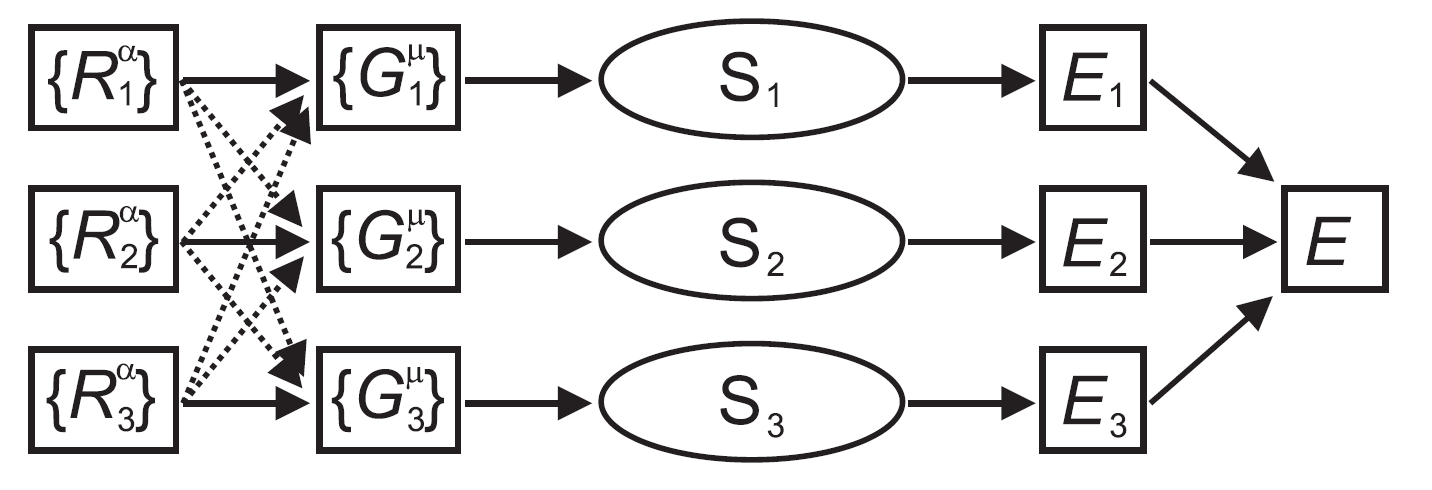

The foundational assumption of our NNP is that the total potential energy of a molecular system or bulk material ($E_{total}$) can be partitioned into localized, individual atomic energy contributions ($E_i$):

$$E_{total} = \sum_{i=1}^{N} E_i$$

Instead of training a neural network to look at the entire 64-atom system at once, which would fail to generalize to systems of different sizes, the neural network is trained to act locally on a single atom's environment.

To guarantee **permutational invariance**, the exact same neural network weights are applied to every atom in the system. Our `FeedForwardNet` class acts as this shared sub-network. Each $S_i$ present in the first image, is build as in the following image:

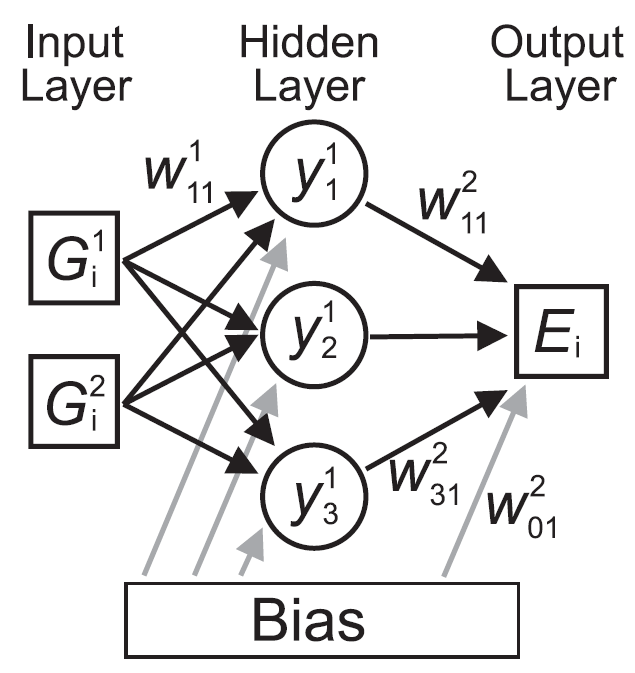


Our PyTorch implementation processes the data in the following sequential steps:

1. **Input Representation:** The network receives a 3D tensor of shape `(batch_size, atoms_per_frame, num_features)`, where `batch_size` is an hyperparameter which is the number of configuration loaded simultaneously inside the network before the gradient update, `atoms_per_frame` is the number of atom in the Silicon bulk, in our case 64, and `num_features` is the number of symmetry functions.


2. **Atomic Sub-Network:** The shared Feed-Forward Neural Network processes each atom's features simultaneously in every $S_i$ sub-network. This consists of `HIDDEN_LAYERS` hidden layers separated by non-linear `GELU` activation functions, mapping the input features down to a latent space of `HIDDEN_SIZE`, and finally to a single output value.


3. **Atomic Energies:** The output of this sub-network $S_i$ is a tensor of shape `(batch_size, atoms_per_frame, 1)`, representing the localized energy contribution $E_i$ of each atom.


4. **Summation:** Finally, a sum reduction is performed across the atomic dimension (`torch.sum(atomic_energies, dim=1)`) to calculate the macroscopic total predicted energy for the entire frame.



The total energy is then compared against the true total potential energy from the LAMMPS dataset to compute the Mean Squared Error (MSE) loss during training.

In [148]:
class FeedForwardNet(nn.Module):
    def __init__(self, in_features=input_features, out_features=1, hidden_layers=3, hidden_size=128, dropout_rate=0.0):
        super().__init__()
        
        # This sequential block represents the atomic neural network
        modules = [nn.Linear(in_features, hidden_size), nn.GELU()]
        for _ in range(hidden_layers - 1):
            modules.append(nn.Linear(hidden_size, hidden_size))
            if dropout_rate > 0:
                modules.append(nn.Dropout(dropout_rate))
            modules.append(nn.GELU())
        modules.append(nn.Linear(hidden_size, out_features))
        
        self.atomic_net = nn.Sequential(*modules)

    def forward(self, x):
        # x input shape: (batch_size_of_frames, atoms_per_frame, 72)
        
        # 1. Calculate individual atomic energy contributions
        atomic_energies = self.atomic_net(x) 
        # atomic_energies shape: (batch_size_of_frames, atoms_per_frame, 1)
        
        # 2. Sum the atomic energies to get the total predicted energy per frame
        total_energy = torch.sum(atomic_energies, dim=1)
        # total_energy shape: (batch_size_of_frames, 1)
        
        return total_energy

In [149]:
# Create model and display architecture with parameter count
model = FeedForwardNet(hidden_layers=HIDDEN_LAYERS, hidden_size=HIDDEN_SIZE, dropout_rate=DROPOUT_RATE).to(device)

experiment_name = ("experiment_hl"+str(HIDDEN_LAYERS)+"_hs"+str(HIDDEN_SIZE)+"_dr"+str(DROPOUT_RATE)+"_bs"+str(BATCH_SIZE)+"_lr"+str(LEARNING_RATE)+"_ep"+str(EPOCHS)+"_pt"+str(PATIENCE)+"_l2"+str(L2_LAMBDA)).replace('.', 'p')
timestamp = datetime.now().strftime("%m%d-%H%M")
experiment_name = f"{experiment_name}_{timestamp}"
print(f"Experiment name: {experiment_name}")

# Aggiungi il grafo su TensorBoard
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_features).to(device)
writer.add_graph(model, x)
writer.close()

# Summary su CPU e poi rimuovi gli hook
if device.type != "cuda":
    summary(model.to("cpu"), input_size=(input_features,))
    model = model.to(device)

    # Rimuovi tutti gli hook rimasti da torchsummary
    for module in model.modules():
        module._forward_hooks.clear()
        module._backward_hooks.clear()

# Compila solo su CUDA (su MPS l'overhead supera il guadagno)
if device.type == "cuda":
    # model = torch.compile(model)
    summary(model, input_size=(input_features,))

Experiment name: experiment_hl2_hs64_dr0p0_bs128_lr0p0001_ep1500_pt75_l20p0_0717-1938
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]           4,736
              GELU-2                   [-1, 64]               0
            Linear-3                   [-1, 64]           4,160
              GELU-4                   [-1, 64]               0
            Linear-5                    [-1, 1]              65
Total params: 8,961
Trainable params: 8,961
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.03
Estimated Total Size (MB): 0.04
----------------------------------------------------------------


In [150]:
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_features).to(device)
writer.add_graph(model, x)
writer.close()

## 🧮 **Network Parameters**

In [151]:
# Set up loss function and optimizer
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Scheduler: ReduceLROnPlateau: reduces the learning rate when a metric has stopped improving. Here, we monitor the validation loss.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=20, min_lr=1e-6   # was 3
)   

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())

## 🧠 **Model Training**

In [152]:
# Initialize best model tracking variables
best_model = None
best_performance = float('inf')

In [153]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Returns:
        tuple: (average_loss, RMSE) - Training loss and RMSE for this epoch
    """
    model.train()

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type in ('cuda', 'mps'))):
            logits = model(inputs)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        all_predictions.append(logits.detach().cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    # Convert to full concatenated numpy arrays first
    targets_flat = np.concatenate(all_targets)
    predictions_flat = np.concatenate(all_predictions)

    # Force both arrays to be exactly 2D: (num_samples, remaining_dimensions_flattened)
    targets_flat = targets_flat.reshape(targets_flat.shape[0], -1)
    predictions_flat = predictions_flat.reshape(predictions_flat.shape[0], -1)

    epoch_rmse = np.sqrt(mean_squared_error(targets_flat, predictions_flat))

    return epoch_loss, epoch_rmse

In [154]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Returns:
        tuple: (average_loss, RMSE) - Validation loss and RMSE for this epoch
    """
    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type in ('cuda', 'mps'))):
                logits = model(inputs)
                loss = criterion(logits, targets)

            running_loss += loss.item() * inputs.size(0)
            all_predictions.append(logits.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    # Convert to full concatenated numpy arrays first
    targets_flat = np.concatenate(all_targets)
    predictions_flat = np.concatenate(all_predictions)

    # Force both arrays to be exactly 2D: (num_samples, remaining_dimensions_flattened)
    targets_flat = targets_flat.reshape(targets_flat.shape[0], -1)
    predictions_flat = predictions_flat.reshape(predictions_flat.shape[0], -1)

    epoch_rmse = np.sqrt(mean_squared_error(targets_flat, predictions_flat))

    return epoch_loss, epoch_rmse

In [155]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_rmse", mode='min',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_rmse")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_rmse': [], 'val_rmse': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    best_val_rmse_print = float('inf')

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_rmse = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_rmse = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Step the scheduler based on validation loss
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        elif isinstance(scheduler, torch.optim.lr_scheduler.CosineAnnealingWarmRestarts):
            scheduler.step()

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_rmse'].append(train_rmse)
        training_history['val_rmse'].append(val_rmse)

        # Check for improvement in val_rmse specifically for printing logic
        is_val_rmse_improvement = False
        if val_rmse < best_val_rmse_print:
            best_val_rmse_print = val_rmse
            is_val_rmse_improvement = True

        # Determine whether to print based on verbose setting
        should_print = False
        if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
            should_print = True
        elif verbose == -1 and is_val_rmse_improvement:
            should_print = True
        elif verbose < -1 and (epoch % abs(verbose) == 0 or is_val_rmse_improvement):
            should_print = True

        # Print progress
        if should_print:
            # Add a visual flag if printing was triggered by an improvement while using a negative verbose

            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Train: Loss={train_loss:.4f}, RMSE={train_rmse:.4f} | "
                  f"Val: Loss={val_loss:.4f}, RMSE={val_rmse:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "./models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("./models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "./models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

In [156]:
%%time
# Train model and track training history
model, training_history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    patience=PATIENCE,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=-10,
    experiment_name=experiment_name
    )

# Update best model if current performance is superior
if training_history['val_rmse'][-1] < best_performance:
    best_model = model
    best_performance = training_history['val_rmse'][-1]

Training 1500 epochs...
Epoch   1/1500 | Train: Loss=137.3520, RMSE=11.7197 | Val: Loss=26.3085, RMSE=5.1292
Epoch   2/1500 | Train: Loss=15.4674, RMSE=3.9329 | Val: Loss=4.3800, RMSE=2.0929
Epoch   3/1500 | Train: Loss=2.9522, RMSE=1.7182 | Val: Loss=2.8145, RMSE=1.6776
Epoch   4/1500 | Train: Loss=2.2042, RMSE=1.4847 | Val: Loss=2.1886, RMSE=1.4794
Epoch   5/1500 | Train: Loss=1.8903, RMSE=1.3749 | Val: Loss=2.0271, RMSE=1.4238
Epoch   6/1500 | Train: Loss=1.7357, RMSE=1.3174 | Val: Loss=1.7939, RMSE=1.3394
Epoch   7/1500 | Train: Loss=1.6222, RMSE=1.2736 | Val: Loss=1.7571, RMSE=1.3255
Epoch   8/1500 | Train: Loss=1.5480, RMSE=1.2442 | Val: Loss=1.6157, RMSE=1.2711
Epoch   9/1500 | Train: Loss=1.4623, RMSE=1.2093 | Val: Loss=1.5169, RMSE=1.2316
Epoch  10/1500 | Train: Loss=1.4357, RMSE=1.1982 | Val: Loss=1.4857, RMSE=1.2189
Epoch  11/1500 | Train: Loss=1.3972, RMSE=1.1820 | Val: Loss=1.4634, RMSE=1.2097
Epoch  12/1500 | Train: Loss=1.3608, RMSE=1.1665 | Val: Loss=1.4157, RMSE=1.1898

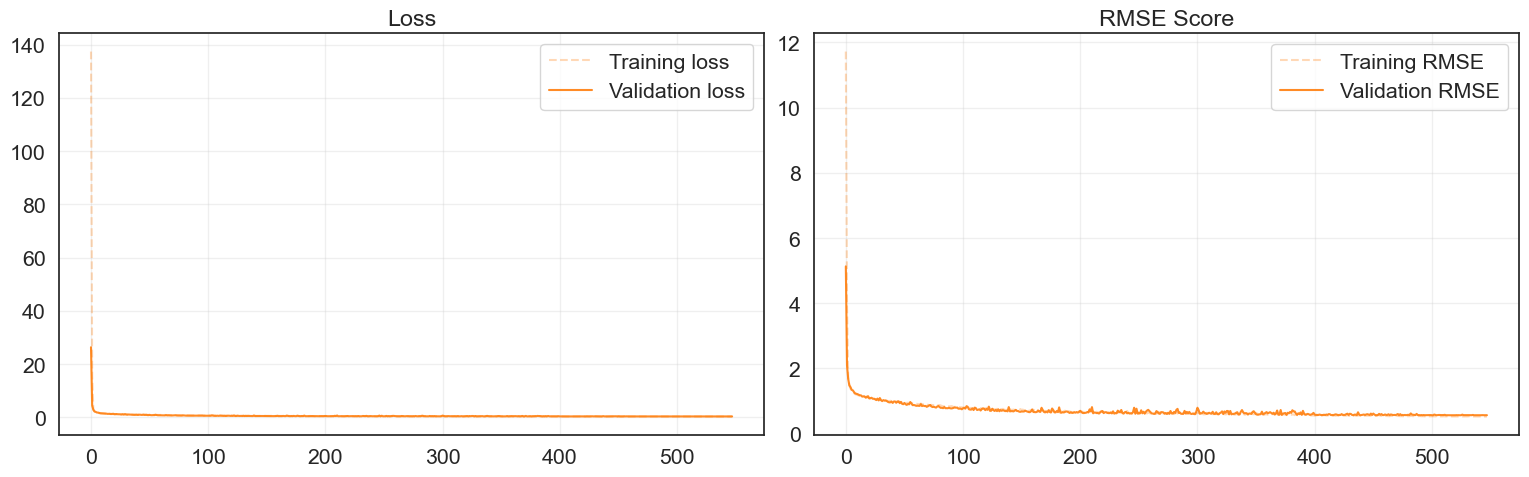

In [157]:
# @title Plot History
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_rmse'], label='Training RMSE', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_rmse'], label='Validation RMSE', alpha=0.9, color='#ff7f0e')
ax2.set_title('RMSE Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Mean Absolute Error (MAE): 0.3378
Root Mean Squared Error (RMSE):  0.5609
R-squared (R2) Score:      0.9992


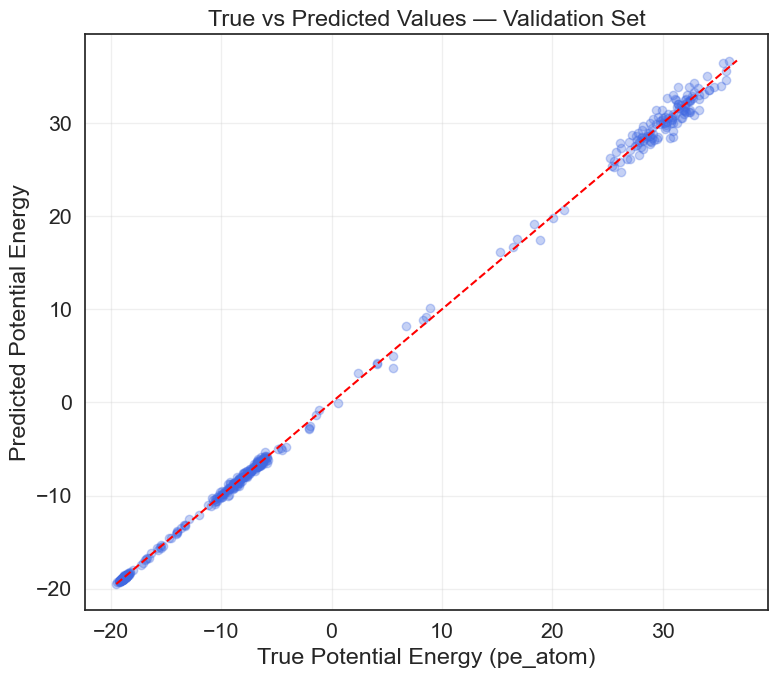

In [158]:
# @title Evaluate Regression Performance
val_preds, val_targets = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)

        val_preds.append(logits.cpu().numpy())
        val_targets.append(yb.cpu().numpy())

val_preds = np.concatenate(val_preds, axis=0)
val_targets = np.concatenate(val_targets, axis=0)

# Calculate overall validation metrics
val_mae = mean_absolute_error(val_targets, val_preds)
val_rmse = np.sqrt(mean_squared_error(val_targets, val_preds))
val_r2 = r2_score(val_targets, val_preds)

print(f"Mean Absolute Error (MAE): {val_mae:.4f}")
print(f"Root Mean Squared Error (RMSE):  {val_rmse:.4f}")
print(f"R-squared (R2) Score:      {val_r2:.4f}")

# Generate Scatter Plot: True vs Predicted
plt.figure(figsize=(8, 7))
plt.scatter(val_targets, val_preds, alpha=0.3, color='royalblue')

# Plot the ideal prediction line (y = x)
min_val = min(val_targets.min(), val_preds.min())
max_val = max(val_targets.max(), val_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('True Potential Energy (pe_atom)')
plt.ylabel('Predicted Potential Energy')
plt.title('True vs Predicted Values — Validation Set')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 🕹️ **Inference**

In [159]:
test_preds_shifted, test_targets_shifted = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in test_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions (these are shifted, centered near 0)
        logits = best_model(xb)

        # Store batch results
        test_preds_shifted.append(logits.cpu().numpy())
        test_targets_shifted.append(yb.cpu().numpy())

# Combine all batches into single arrays
test_preds_shifted = np.concatenate(test_preds_shifted)
test_targets_shifted = np.concatenate(test_targets_shifted)
test_preds = test_preds_shifted + mean_total_energy
test_targets = test_targets_shifted + mean_total_energy

Mean Absolute Error (MAE) over the test set: 0.3415
Root Mean Squared Error (RMSE) over the test set:  0.5478
R-squared (R2) score over the test set:      0.9992
Root Mean Squared Error (RMSE) per atom over the test set:  8.5589 meV/atom


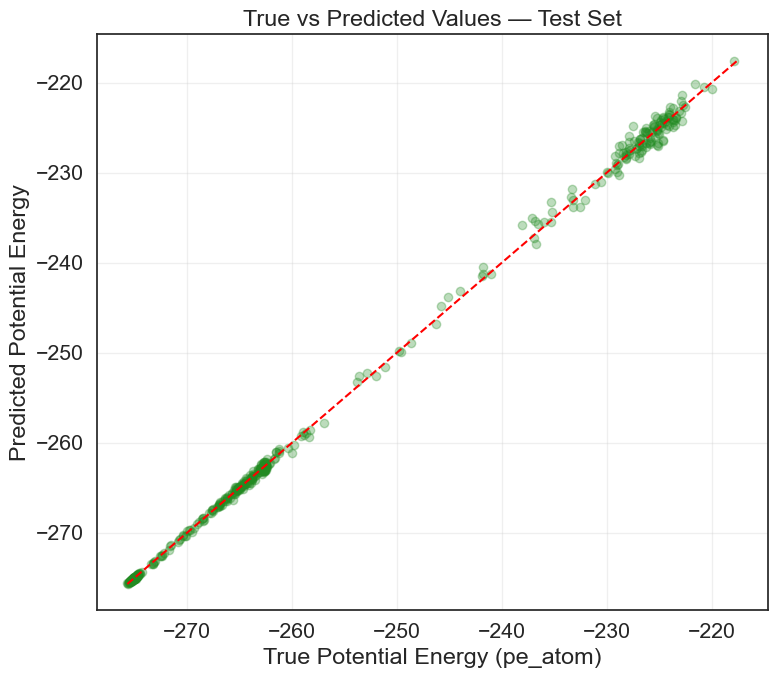

In [160]:
# Calculate overall test metrics for regression
test_mae = mean_absolute_error(test_targets, test_preds)
test_mse = np.sqrt(mean_squared_error(test_targets, test_preds))
test_r2 = r2_score(test_targets, test_preds)

print(f"Mean Absolute Error (MAE) over the test set: {test_mae:.4f}")
print(f"Root Mean Squared Error (RMSE) over the test set:  {test_mse:.4f}")
print(f"R-squared (R2) score over the test set:      {test_r2:.4f}")
print(f"Root Mean Squared Error (RMSE) per atom over the test set:  {test_mse/n_atoms * 1000:.4f} meV/atom")

# Generate Scatter Plot: True vs Predicted for the Test Set
plt.figure(figsize=(8, 7))
# Using a different color (e.g., forestgreen) to distinguish from the validation plot
plt.scatter(test_targets, test_preds, alpha=0.3, color='forestgreen')

# Plot the ideal prediction line (y = x) where true == predicted
min_val = min(test_targets.min(), test_preds.min())
max_val = max(test_targets.max(), test_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('True Potential Energy (pe_atom)')
plt.ylabel('Predicted Potential Energy')
plt.title('True vs Predicted Values — Test Set')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save experiment results to history.txt
with open('history.txt', 'a') as f:
    f.write(f"{experiment_name}\tRMSE: {test_mse:.4f}\n")

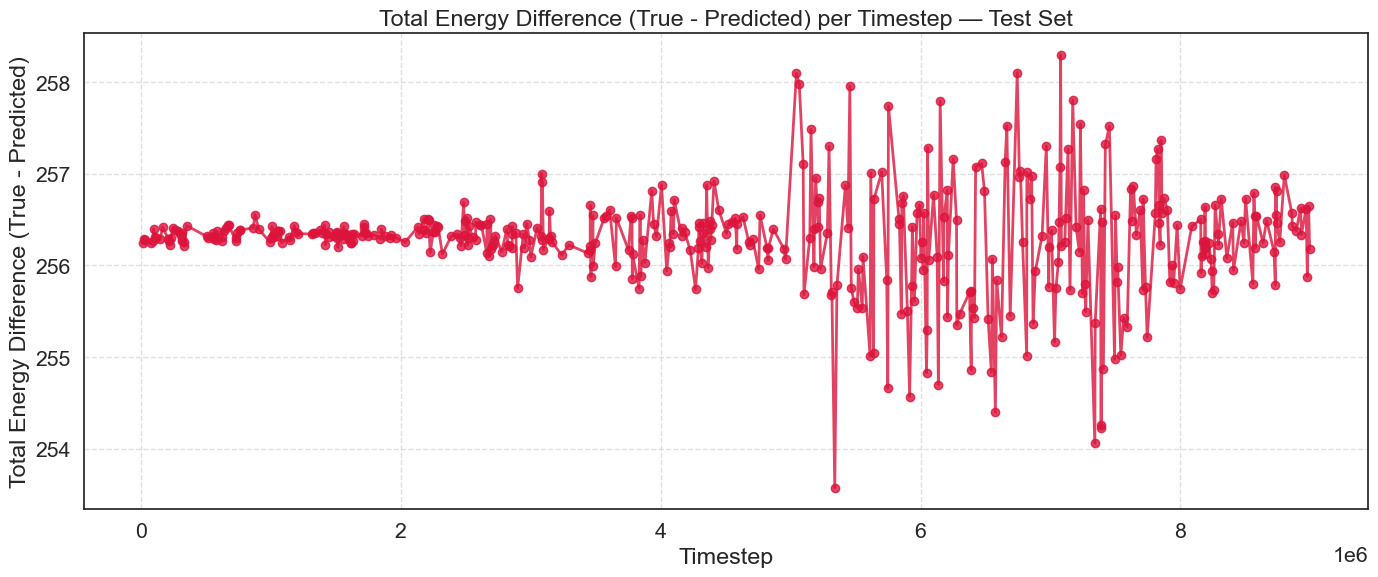

Frame-Level Total Energy Error Statistics:


count    451.000000
mean     256.286116
std        0.547710
min      253.577748
25%      256.158835
50%      256.325020
75%      256.480516
max      258.295292
Name: energy_diff, dtype: float64

In [161]:
test_timesteps = test_df.groupby('frame_id')['timestep'].first().values
test_preds_physical = test_preds.flatten() + mean_total_energy 

energy_per_timestep = pd.DataFrame({
    'timestep': test_timesteps, 
    'true_energy': y_test_total.flatten(),       # <- Real physical energy
    'predicted_energy': test_preds_physical      # <- Real predicted energy
}).sort_values('timestep')

# Calculate the residuals (energy difference/error)
energy_per_timestep['energy_diff'] = energy_per_timestep['true_energy'] - energy_per_timestep['predicted_energy']

plt.figure(figsize=(14, 6))
plt.plot(
    energy_per_timestep['timestep'],
    energy_per_timestep['energy_diff'],
    marker='o',
    linestyle='-',
    color='crimson',
    linewidth=2,
    alpha=0.8
)

plt.title('Total Energy Difference (True - Predicted) per Timestep — Test Set')
plt.xlabel('Timestep')
plt.ylabel('Total Energy Difference (True - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 6. Display error statistics for the frame-level predictions
print("Frame-Level Total Energy Error Statistics:")
display(energy_per_timestep['energy_diff'].describe())

## 💪🏻 Forces

In classical molecular dynamics, the force vector $\mathbf{F}_i$ acting on an atom $i$ is fundamentally defined as the negative gradient of the total potential energy $E_{total}$ with respect to the atom's Cartesian coordinates $\mathbf{R}_i$:

$$\mathbf{F}_i = -\nabla_{\mathbf{R}_i} E_{total} = -\left( \frac{\partial E_{total}}{\partial x_i}, \frac{\partial E_{total}}{\partial y_i}, \frac{\partial E_{total}}{\partial z_i} \right) = - \left (\sum_{j} \frac{\partial E_{total}}{\partial G_j} \frac{\partial G_j}{\partial x_i}, \sum_{j} \frac{\partial E_{total}}{\partial G_j} \frac{\partial G_j}{\partial y_i}, \sum_{j} \frac{\partial E_{total}}{\partial G_j} \frac{\partial G_j}{\partial z_i} \right )$$

### PyTorch Automatic Differentiation (Autograd)

To compute exact, analytical forces, we leverage PyTorch's `autograd` engine. The computational workflow is designed as follows:

1. **Gradient Tracking (`requires_grad=True`):** The input Cartesian coordinates $\mathbf{R}$ are loaded as a PyTorch tensor with gradient tracking explicitly enabled. This instructs PyTorch to record every mathematical operation applied to these coordinates into a dynamic computational graph.


2. **The Forward Pass:** The coordinates are transformed into symmetry functions ($G$) and passed through the trained neural network to yield the total predicted potential energy $E_{pred}$.


3. **The Backward Pass:** We apply the `torch.autograd.grad()` function to compute the derivative of the output energy with respect to the input Cartesian coordinates. By negating this result ($-dE/dR$), the engine traces back through the network layers and the symmetry function equations to instantly yield the analytical force components $(F_x, F_y, F_z)$ for every atom in the system.



This mechanism guarantees that the forces used in our subsequent Molecular Dynamics simulations are the exact derivatives of our trained energy surface.

In [162]:
# 1. Set the best model to evaluation mode
best_model.eval()

# Same values as before
Rc_val = 3.7712
r_low = 2.0
r_upp = 3.5

eta_radial, Rs_grid, eta_angular, lambda_grid, zeta_grid = get_gastegger_shifted_params(
        N_RADIAL=N_RADIAL, 
        r_low=2.0, 
        r_upp=3.5
    )

# Convert symmetry function parameters to tensors
eta_radial_t  = torch.tensor(eta_radial, dtype=torch.float32, device=device)
Rs_grid_t     = torch.tensor(Rs_grid, dtype=torch.float32, device=device)
eta_angular_t = torch.tensor(eta_angular, dtype=torch.float32, device=device)
zeta_grid_t   = torch.tensor(zeta_grid, dtype=torch.float32, device=device)
lambda_grid_t = torch.tensor(lambda_grid, dtype=torch.float32, device=device)

# 3. Extract coordinates (x,y,z) and true forces (fx,fy,fz) from the validation dataframe
coords_val = val_df[['x', 'y', 'z']].values.reshape(-1, 64, 3)
forces_true_val = val_df[['fx', 'fy', 'fz']].values.reshape(-1, 64, 3)

box_lengths_t = torch.tensor([val_df['box_x'].iloc[0], val_df['box_y'].iloc[0], val_df['box_z'].iloc[0]], dtype=torch.float32, device=device)

n_frames_val = coords_val.shape[0]
all_pred_cartesians = []
all_true_cartesians = []

# Use a small batch size to prevent MPS memory saturation
batch_size_val = 2 

for i in tqdm(range(0, n_frames_val, batch_size_val), desc="Extracting Cartesian Forces"):
    batch_coords = coords_val[i : i + batch_size_val]
    batch_forces_true = forces_true_val[i : i + batch_size_val]
    
    # Cartesian position tensor with requires_grad=True
    R_tensor = torch.tensor(batch_coords, dtype=torch.float32, device=device)
    R_tensor.requires_grad_(True)
    
    # Recompute symmetry functions on-the-fly to keep the computation graph intact
    G_features = compute_symmetry_functions_vectorized(
        coords_3d=R_tensor,
        Rc=Rc_val,
        eta_rad=eta_radial_t,
        Rs=Rs_grid_t,
        eta_ang=eta_angular_t,
        zeta=zeta_grid_t,
        lmbda=lambda_grid_t,
        pbc=True,
        box_lengths=box_lengths_t
    )

    
    # Apply feature scaling using the scaler parameters from training
    mean_t = torch.tensor(feature_scaler.mean_, dtype=torch.float32, device=device)
    scale_t = torch.tensor(feature_scaler.scale_, dtype=torch.float32, device=device)
    
    # We need to match the input shape exactly to feature_scaler.n_features_in_
    expected_dim = feature_scaler.n_features_in_
    current_dim = G_features.shape[-1]
    
    if current_dim < expected_dim:
        # Pad with zeros to reach the expected dimensionality
        padding = torch.zeros((*G_features.shape[:-1], expected_dim - current_dim), 
                              device=device, dtype=torch.float32)
        G_features = torch.cat([G_features, padding], dim=-1)
    elif current_dim > expected_dim:
        # Truncate if we have too many
        G_features = G_features[..., :expected_dim]
    
    # Scale the aligned features
    G_scaled = (G_features - mean_t) / scale_t
    
    # Forward pass
    E_pred = best_model(G_scaled)
    
    # True Cartesian gradient calculation (F = - dE/dR)
    F_pred = -torch.autograd.grad(
        outputs=E_pred,
        inputs=R_tensor,
        grad_outputs=torch.ones_like(E_pred),
        create_graph=False,
        retain_graph=False
    )[0]
    
    all_pred_cartesians.append(F_pred.detach().cpu().numpy())
    all_true_cartesians.append(batch_forces_true)
    
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()

# Concatenate and calculate RMSE on Cartesian forces
all_pred_cartesians = np.concatenate(all_pred_cartesians, axis=0)
all_true_cartesians = np.concatenate(all_true_cartesians, axis=0)


Extracting Cartesian Forces:   0%|          | 0/225 [00:00<?, ?it/s]

Extracting Cartesian Forces: 100%|██████████| 225/225 [00:11<00:00, 19.99it/s]



FORCE EVALUATION RESULTS (Energy Model vs Stillinger-Weber)
Predicted forces shape: (450, 64, 3)
RMSE on Cartesian Forces: 0.8604 eV/Å
RMSE Fx: 0.8588 eV/Å
RMSE Fy: 0.8618 eV/Å
RMSE Fz: 0.8604 eV/Å


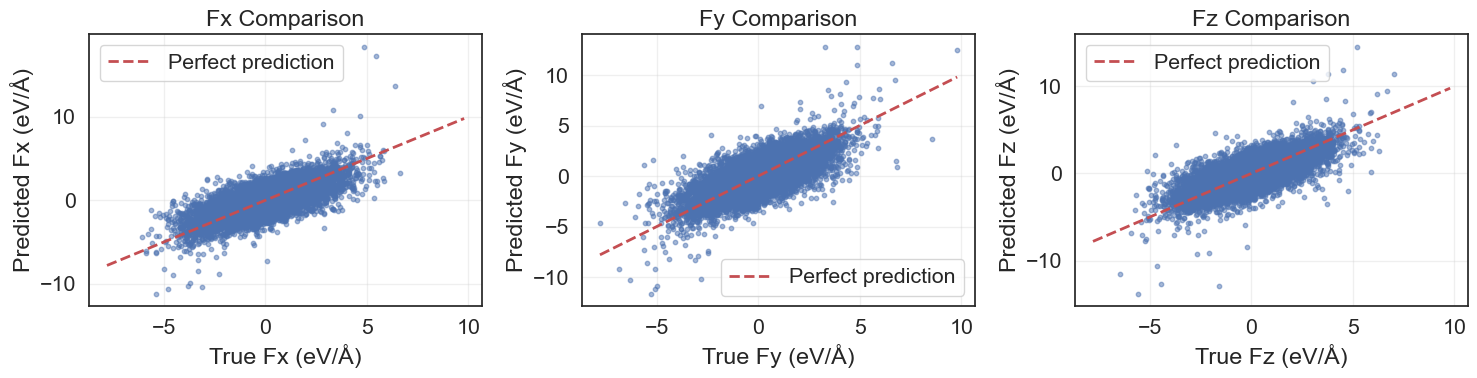

In [163]:
rmse_forces = np.sqrt(mean_squared_error(all_true_cartesians.flatten(), all_pred_cartesians.flatten()))

force_components = ['Fx', 'Fy', 'Fz']

print("\n" + "="*50)
print(f"FORCE EVALUATION RESULTS (Energy Model vs Stillinger-Weber)")
print(f"Predicted forces shape: {all_pred_cartesians.shape}")
print(f"RMSE on Cartesian Forces: {rmse_forces:.4f} eV/Å")
for idx, component in enumerate(force_components):
    rmse = np.sqrt(mean_squared_error(all_true_cartesians[:, :, idx].flatten(), 
                                       all_pred_cartesians[:, :, idx].flatten()))
    print(f"RMSE {component}: {rmse:.4f} eV/Å")
print("="*50)

# Create scatter plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, ax in enumerate(axes):
    ax.scatter(all_true_cartesians[:, :, idx].flatten(), 
               all_pred_cartesians[:, :, idx].flatten(), 
               alpha=0.5, s=10)
    ax.plot([all_true_cartesians.min(), all_true_cartesians.max()], 
            [all_true_cartesians.min(), all_true_cartesians.max()], 
            'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel(f'True {force_components[idx]} (eV/Å)')
    ax.set_ylabel(f'Predicted {force_components[idx]} (eV/Å)')
    ax.set_title(f'{force_components[idx]} Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📈 Molecular Dynamics

To perform molecular dynamics, we need to simulate the physical movement of the Silicon atoms over time, we need to integrate Newton's equations of motion. For this project, we implemented the **Velocity Verlet algorithm** from scratch.

The algorithm progresses the state of the system by a discrete time step $\Delta t$ through a four-step process:

1. **First Half-Step for Velocities:** We update the velocities by a half time step using the current accelerations (derived from the NNP-predicted forces):



$$\mathbf{v}\left(t + \frac{\Delta t}{2}\right) = \mathbf{v}(t) + \frac{1}{2} \mathbf{a}(t) \Delta t$$


2. **Full-Step for Positions:** We then update the atomic positions by a full time step using these newly calculated half-step velocities:



$$\mathbf{r}(t + \Delta t) = \mathbf{r}(t) + \mathbf{v}\left(t + \frac{\Delta t}{2}\right) \Delta t$$



*(At this stage, Periodic Boundary Conditions are applied to ensure atoms wrapping past the box boundaries re-enter on the opposite side)*.


3. **Force Re-evaluation:** With the atoms in their new positions, we query our Neural Network Potential to compute the new forces $\mathbf{F}$ and, consequently, the new accelerations:



$$\mathbf{a}(t + \Delta t) = \frac{\mathbf{F}(\mathbf{r}(t + \Delta t))}{m}$$


4. **Second Half-Step for Velocities:** Finally, we complete the time step by updating the velocities for the remaining half step using the new accelerations:



$$\mathbf{v}(t + \Delta t) = \mathbf{v}\left(t + \frac{\Delta t}{2}\right) + \frac{1}{2} \mathbf{a}(t + \Delta t) \Delta t$$

In [164]:
atomic_mass_Si = 28.0855 
# Temperature initialization
temperature_desired = 300.0  # K

N_STEPS = 10000
dt = 1e-3  # Time step in picoseconds

# Force conversion factor from eV/Å to kcal/mol/Å
FORCE_CONVERSION = 9648.5332

In [165]:
# Initial Velocities are sampled from a Maxwell-Boltzmann distribution
kB = 1.380649e-23
amu_to_kg = 1.66053906660e-27
A_per_ps_to_m_per_s = 1e2

sigma_m_s = np.sqrt(kB * temperature_desired / (atomic_mass_Si * amu_to_kg))
sigma_A_ps = sigma_m_s / A_per_ps_to_m_per_s

velocities = rng.normal(loc=0.0, scale=sigma_A_ps, size=(n_atoms, 3))

# remove center-of-mass drift
velocities -= velocities.mean(axis=0, keepdims=True)

# rescale to match the target temperature exactly
velocities_m_s = velocities * A_per_ps_to_m_per_s
current_T = (atomic_mass_Si * amu_to_kg * np.mean(velocities_m_s**2)) / kB
velocities *= np.sqrt(temperature_desired / current_T)

positions = silicon_dataset[['x', 'y', 'z']].iloc[n_atoms:2*n_atoms].values.copy()

box_lengths_np = np.array([silicon_dataset['box_x'].iloc[0], 
                           silicon_dataset['box_y'].iloc[0], 
                           silicon_dataset['box_z'].iloc[0]])

output_dynamic_filename = f"md_simulation_{experiment_name}.xyz"

In [166]:
def compute_nn_forces(pos_numpy):
    R_tensor = torch.tensor(pos_numpy, dtype=torch.float32, device=device)
    R_tensor.requires_grad_(True)

    G_features = compute_symmetry_functions_vectorized(
        coords_3d=R_tensor.unsqueeze(0), # Adds the batch dimension: (1, N, 3)
        Rc=Rc_val,
        eta_rad=eta_radial_t,
        Rs=Rs_grid_t,
        eta_ang=eta_angular_t,
        zeta=zeta_grid_t,
        lmbda=lambda_grid_t,
        pbc=True,
        box_lengths=box_lengths_t
    )

    mean_t = torch.tensor(feature_scaler.mean_, dtype=torch.float32, device=device)
    scale_t = torch.tensor(feature_scaler.scale_, dtype=torch.float32, device=device)
    
    expected_dim = feature_scaler.n_features_in_
    current_dim = G_features.shape[-1]
    
    if current_dim < expected_dim:
        padding = torch.zeros((*G_features.shape[:-1], expected_dim - current_dim), 
                              device=device, dtype=torch.float32)
        G_features = torch.cat([G_features, padding], dim=-1)
    elif current_dim > expected_dim:
        G_features = G_features[..., :expected_dim]
    
    G_scaled = (G_features - mean_t) / scale_t
    E_pred = best_model(G_scaled)

    F_pred = -torch.autograd.grad(
        outputs=E_pred,
        inputs=R_tensor,
        grad_outputs=torch.ones_like(E_pred),
        create_graph=False,
        retain_graph=False
    )[0]
    
    # Removes the batch dimension and converts back to a NumPy array
    return F_pred.squeeze(0).detach().cpu().numpy()

In [167]:
current_forces = compute_nn_forces(positions)

trajectory_velocities = []

# Initialize the XYZ file
with open(output_dynamic_filename, 'w') as f:
    pass 

for i in tqdm(range(N_STEPS), desc="Running MD Simulation"):
    
    # STEP 1: Update velocities by half a timestep (dt/2) using current forces
    accelerations = (current_forces / atomic_mass_Si) * FORCE_CONVERSION
    velocities += 0.5 * accelerations * dt
    
    # STEP 2: Update positions by a full timestep (dt)
    positions += velocities * dt
    
    # Apply Periodic Boundary Conditions (wrap positions back inside the simulation box)
    positions = positions % box_lengths_np
    
    # STEP 3: Compute NEW forces based on the updated positions
    current_forces = compute_nn_forces(positions)
    
    # STEP 4: Update velocities again by the remaining half timestep (dt/2)
    accelerations = (current_forces / atomic_mass_Si) * FORCE_CONVERSION
    velocities += 0.5 * accelerations * dt
    
    trajectory_velocities.append(velocities.copy())
    
    # Log the trajectory (runs every 10 steps)
    if i % 10 == 0:
        with open(output_dynamic_filename, 'a') as f:
            f.write(f"{n_atoms}\n")
            f.write(f"Step {i}\n")
            for atom_id in range(n_atoms):
                x, y, z = positions[atom_id]
                f.write(f"Si {x:.6f} {y:.6f} {z:.6f}\n")

trajectory_velocities = np.array(trajectory_velocities)

Running MD Simulation: 100%|██████████| 10000/10000 [03:02<00:00, 54.69it/s]


## 🔥MÜLLER-PLATHE

To evaluate the power of our NNP, we try to predict the thermal conductivity of our simulated Silicon system, implementing the **Müller-Plathe algorithm**, also known as Reverse Non-Equilibrium Molecular Dynamics (RNEMD).

The algorithm operates as follows:

1. **Slabbing of the box**: We divide the box into `N_SLABS` equals slabs and assign each atom to each slab.

1. **Velocity Swapping:** Periodically (every `SWAP_INTERVAL` steps), we identify the coldest atom in the designated "hot slab" (the center of the box) and the hottest atom in the "cold slab" (the bottom of the box).


2. **Energy Transfer:** We swap their velocity vectors. This non-physical swap artificially transports kinetic energy from the cold slab to the hot slab without drifting the total momentum of the system.


3. **Induced Gradient:** Because energy is constantly being forced from the edges to the center, the standard physical response of the system is to flow heat back outwards to re-equilibrate. This establishes a steady-state temperature profile.

By tracking the exact amount of kinetic energy exchanged during the swaps ($\Delta E$), we can calculate the imposed heat flux ($J_z$):


$$J_z = \frac{\sum \Delta E}{2 t A}$$


*(Where $t$ is the simulation time and $A$ is the cross-sectional area of a slab; the factor of 2 accounts for the periodic boundary conditions allowing heat to flow in two directions)*.

Finally, the thermal conductivity $k$ is extracted using Fourier's Law by fitting the linear slope of the established temperature gradient ($dT/dz$):


$$k = \frac{J_z}{\nabla T} = \frac{J_z}{dT/dz}$$

### ⚠️ A Note on Results and Computational Limitations

We suppose, also by comparing our code with others found, that the algorithm was implemented correctly, however the calculated thermal conductivity $k = 0.28 \text{ } W/(m \cdot K)$ is very poor and not physically representative of bulk Silicon, which has an experimental thermal conductivity $k = 148 \text{ } W/(m \cdot K)$.

**The reason for this inaccuracy is strictly computational.** A stable and statistically meaningful Müller-Plathe calculation requires the system to reach a robust steady state, which typically takes millions of iterations. To achieve a realistic value, the simulation was designed for **2,000,000 steps**. However, running this through our custom NNP would require roughly 9 hours of continuous computation time.

To keep the notebook executable and demonstrate the *methodology* rather than the final physical property, we drastically truncated the run to just **100,000 steps** (with only 20,000 steps allocated for equilibration). As a result, the temperature profile is heavily influenced by noise, and the thermal steady state was not fully achieved.


In [168]:
# Initial Velocities are sampled from a Maxwell-Boltzmann distribution
sigma_m_s = np.sqrt(kB * temperature_desired / (atomic_mass_Si * amu_to_kg))
sigma_A_ps = sigma_m_s / A_per_ps_to_m_per_s

velocities = rng.normal(loc=0.0, scale=sigma_A_ps, size=(n_atoms, 3))

# remove center-of-mass drift
velocities -= velocities.mean(axis=0, keepdims=True)

# rescale to match the target temperature exactly
velocities_m_s = velocities * A_per_ps_to_m_per_s
current_T = (atomic_mass_Si * amu_to_kg * np.mean(velocities_m_s**2)) / kB
velocities *= np.sqrt(temperature_desired / current_T)

positions = silicon_dataset[['x', 'y', 'z']].iloc[:n_atoms].values.copy() # Takes the first frame's positions

In [169]:
# Muller-Plathe Reverse NEMD Parameters

# Right parameters, but it take 9 hours to compute
# N_STEPS = 2000000
# N_SLABS = 20             
# SWAP_INTERVAL = 100    
# EQUILIBRATION_STEPS = 100000    

N_STEPS = 100000
N_SLABS = 20                    # Number slabs along the Z-axis for temperature profiling
SWAP_INTERVAL = 50              # Interval (in MD steps) to perform the Müller-Plathe velocity swap
EQUILIBRATION_STEPS = 20000     # Steps to allow the system to equilibrate before sampling temperatures

hot_slab_idx = N_SLABS // 2 # Center slab (z=Lz/2) for heating
cold_slab_idx = 0           # Bottom slab (z=0) for cooling

# Variables to trace energy exchange and slab temperatures
total_energy_exchanged_Joules = 0.0
slab_temperatures_accum = np.zeros(N_SLABS)
slab_counts = np.zeros(N_SLABS)
samples_taken = 0

# Dimension of the simulation box along Z and slab thickness
Lz = box_lengths_np[2]
slab_thickness = Lz / N_SLABS
Area = box_lengths_np[0] * box_lengths_np[1] # Area XY in Å^2
Area_m2 = Area * 1e-20                       # Area XY in m^2


In [170]:
# Loops over MD steps with Müller-Plathe velocity swapping and temperature sampling
current_forces = compute_nn_forces(positions)

for i in tqdm(range(N_STEPS), desc="MD Simulation with Müller-Plathe"):
    
    # Velocity Verlet Integration half-step
    accelerations = (current_forces / atomic_mass_Si) * FORCE_CONVERSION
    velocities += 0.5 * accelerations * dt
    positions += velocities * dt
    positions = positions % box_lengths_np
    
    # Müller-Plathe Velocity Swapping
    # Determine which slab each atom belongs to based on its Z-coordinate
    z_coords = positions[:, 2]
    slab_assignments = (z_coords / slab_thickness).astype(int) % N_SLABS
    
    if i % SWAP_INTERVAL == 0:
        # Find atoms in the hot and cold slabs
        hot_slab_atoms = np.where(slab_assignments == hot_slab_idx)[0]
        cold_slab_atoms = np.where(slab_assignments == cold_slab_idx)[0]
        
        if len(hot_slab_atoms) > 0 and len(cold_slab_atoms) > 0:
            # Compute squared velocities for atoms in hot and cold slabs
            v2_hot = np.sum(velocities[hot_slab_atoms]**2, axis=1)
            v2_cold = np.sum(velocities[cold_slab_atoms]**2, axis=1)
            
            # Find the indices of the coldest atom in the hot slab and the hottest atom in the cold slab
            idx_coldest_in_hot = hot_slab_atoms[np.argmin(v2_hot)]
            idx_hottest_in_cold = cold_slab_atoms[np.argmax(v2_cold)]
            
            v2_min_hot = np.min(v2_hot)
            v2_max_cold = np.max(v2_cold)
            
            # Make the swap only if the coldest in hot is colder than the hottest in cold
            if v2_max_cold > v2_min_hot:
                # Compute the energy exchanged during the swap in Joules as
                # $$\Delta E = \frac{1}{2} m v_{\text{hot}}^2 - \frac{1}{2} m v_{\text{cold}}^2$$
                v_max_cold_ms = np.sqrt(v2_max_cold) * 100.0
                v_min_hot_ms = np.sqrt(v2_min_hot) * 100.0
                mass_kg = atomic_mass_Si * amu_to_kg
                
                delta_E = 0.5 * mass_kg * (v_max_cold_ms**2 - v_min_hot_ms**2)
                total_energy_exchanged_Joules += delta_E
                
                # Swap the velocities of the identified atoms
                temp_v = velocities[idx_coldest_in_hot].copy()
                velocities[idx_coldest_in_hot] = velocities[idx_hottest_in_cold]
                velocities[idx_hottest_in_cold] = temp_v

    # Velocity Verlet Integration full-step
    current_forces = compute_nn_forces(positions)
    accelerations = (current_forces / atomic_mass_Si) * FORCE_CONVERSION
    velocities += 0.5 * accelerations * dt

    # Temperature Sampling for Each Slab
    # Start sampling after the equilibration period to ensure accurate temperature readings
    if i > EQUILIBRATION_STEPS:
        for s in range(N_SLABS):
            atoms_in_s = np.where(slab_assignments == s)[0]
            if len(atoms_in_s) > 0:
                v_sq = np.sum(velocities[atoms_in_s]**2)
                v_m_s_sq = v_sq * (100.0**2) # Convert from Å/ps to m/s
                # T = (m * v^2) / (3 * N * kB)
                T_slab = (atomic_mass_Si * amu_to_kg * v_m_s_sq) / (3 * len(atoms_in_s) * kB)
                
                slab_temperatures_accum[s] += T_slab
                slab_counts[s] += 1
        samples_taken += 1

MD Simulation with Müller-Plathe: 100%|██████████| 100000/100000 [30:49<00:00, 54.05it/s]


In [171]:
# Compute average temperatures for each slab after the simulations
indexs = ~np.isnan(slab_temperatures_accum)
slab_temperatures_accum_valid = slab_temperatures_accum.copy()
slab_temperatures_accum_valid[~indexs] = 0.0
avg_slab_temperatures = slab_temperatures_accum_valid / slab_counts
z_centers = (np.arange(N_SLABS) + 0.5) * slab_thickness # Z-coordinates of slab centers

# Compute the heat flux Jz using the total energy exchanged and the time measured
# $$J_z = \frac{\sum \Delta E}{2 t A}$$ 2 factor for pbc
# Total time measured in seconds (dt is in picoseconds, so convert to seconds)
time_measured_s = (N_STEPS - EQUILIBRATION_STEPS) * dt * 1e-12 
Jz = total_energy_exchanged_Joules / (2 * time_measured_s * Area_m2) 
print(f"Thermal flux Jz: {Jz:.2e} W/m^2")

Thermal flux Jz: 4.33e+10 W/m^2


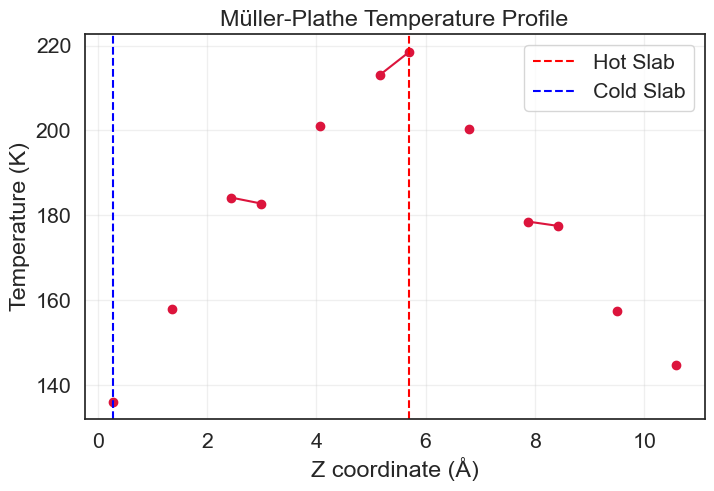

In [172]:
# Plot the temperature profile along the Z-axis

plt.figure(figsize=(8, 5))
plt.plot(z_centers, avg_slab_temperatures, 'o-', color='crimson')
plt.axvline(x=z_centers[hot_slab_idx], color='red', linestyle='--', label='Hot Slab')
plt.axvline(x=z_centers[cold_slab_idx], color='blue', linestyle='--', label='Cold Slab')
plt.xlabel('Z coordinate (Å)')
plt.ylabel('Temperature (K)')
plt.title('Müller-Plathe Temperature Profile')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [173]:
# Thermal Conductivity Calculation using Fourier's Law

# Search for the indices of the hot and cold slabs in the temperature profile
left_region_idx = np.arange(cold_slab_idx, hot_slab_idx + 1)
right_region_idx = np.arange(hot_slab_idx, N_SLABS)

# Extract the Z-coordinates and average temperatures for the left and right regions
z_left = z_centers[left_region_idx]
T_left = avg_slab_temperatures[left_region_idx]

z_right = z_centers[right_region_idx]
T_right = avg_slab_temperatures[right_region_idx]

# filters for empty slabs (NaN values) in the temperature profile
valid_left = ~np.isnan(T_left)
valid_right = ~np.isnan(T_right)
z_left_valid = z_left[valid_left]
T_left_valid = T_left[valid_left]

z_right_valid = z_right[valid_right]
T_right_valid = T_right[valid_right]

# Linear fitting to determine the temperature gradients in both regions
slope_left, intercept_left = np.polyfit(z_left_valid, T_left_valid, 1)
slope_right, intercept_right = np.polyfit(z_right_valid, T_right_valid, 1)
# Compute the mean temperature gradient (in K/Å) across the two regions
avg_gradient_K_per_A = (np.abs(slope_left) + np.abs(slope_right)) / 2.0
avg_gradient_K_per_m = avg_gradient_K_per_A * 1e10

# Fourier Law: k = Jz / (dT/dz)
thermal_conductivity = Jz / avg_gradient_K_per_m

print("-" * 40)
print(f"Mean temperature gradient: {avg_gradient_K_per_A:.2f} K/Å")
print(f"Thermal conductivity (k): {thermal_conductivity:.2f} W/(m*K)")
print("-" * 40)

----------------------------------------
Mean temperature gradient: 14.99 K/Å
Thermal conductivity (k): 0.29 W/(m*K)
----------------------------------------


## ⭕ Radial Distribution Function

The **Radial Distribution Function (RDF)**, denoted as $g(r)$, is a fundamental statistical tool used to characterize the local structural arrangement of atoms in a system. It provides a measure of the probability of finding an atom at a distance $r$ from a reference atom, relative to the probability expected for a completely random distribution.

* **$g(r) = 0$**: indicates that no atoms are found at this distance.


* **Peaks**: Each peak in the RDF corresponds to a "coordination shell" of neighboring atoms, the array of atoms directly attached to the central atom. The first peak it's usually the most intense one, it corresponds to the distance to the very closest atoms. Because Silicon has a diamond structure, these atoms are at a fixed, precise distance (approx. 2.35 Å). Since almost every atom has neighbors at exactly this distance, the probability density here is extremely high, creating a sharp, tall peak. The second peak represents atoms that are slightly further away—for example, the neighbors of your neighbors. Because these atoms are also locked into specific positions by the diamond lattice geometry, they appear at a second, consistent distance, forming another distinct peak

#### Computational Workflow

In this project, we calculated the RDF "from scratch" based on our simulated trajectory. The computation follows these steps:

1. **Distance Calculation:** For every frame in the simulation, we calculate the distance between all pairs of atoms, applying the "minimum image convention" to account for the periodic boundary conditions, so if the distance exceeds half the box length, the "nearest" atom is the one in the adjacent periodic image.


2. **Histogram Binning:** We bin these distances into a histogram representing the number of neighbors found within each distance interval $[r, r + dr]$.


3. **Normalization:** The histogram is normalized by the volume of the spherical shells ($4\pi r^2 dr$) and the average particle density ($\rho = N/V$). This ensures that the RDF reflects the structural distribution rather than just the geometry of the simulation box.



In our analysis, the RDF provides a rigorous structural fingerprint, allowing us to confirm whether the simulated system maintains its crystalline diamond structure or transitions into an amorphous state during the quenching phase.

In [174]:
def compute_rdf(trajectory, box_lengths, nbins=100, rmax=None):
    """
    Compute the radial distribution function (RDF) for a given trajectory of atomic positions.

    Args:
        trajectory_positions (np.ndarray): Array of shape (n_steps, n_atoms, 3) containing atomic positions.
        box_lengths (np.ndarray): Array of shape (3,) containing the lengths of the simulation box in x, y, z.
        num_bins (int): Number of bins for the RDF histogram.
        r_max (float): Maximum distance to consider for RDF. If None, it will be set to half the minimum box length.
    """
    dr = rmax / nbins
    avg_rdf_histogram = np.zeros(nbins)

    # Iterate through each frame in the trajectory to compute the RDF
    for atoms in trajectory:
        coords = atoms.get_positions()
        n_atoms = len(coords)
        frame_rdf = np.zeros(nbins)
        
        for i in range(n_atoms):
            for j in range(i + 1, n_atoms):
                # Vettore distanza tra l'atomo i e l'atomo j
                diff = coords[i] - coords[j]
                
                # Apply periodic boundary conditions (PBC) using the minimum image convention,
                # if the distance exceeds half the box length, the "nearest" atom is the one in the adjacent periodic image.
                diff -= box_lengths * np.round(diff / box_lengths)
                dist = np.linalg.norm(diff)
                
                # If distance is within the maximum radius, update the RDF histogram
                if dist < rmax:
                    bin_idx = int(dist / dr)
                    if bin_idx < nbins:
                        frame_rdf[bin_idx] += 2 # Conta sia la coppia i-j che j-i
                        
        avg_rdf_histogram += frame_rdf

    # Average the RDF histogram over all frames
    avg_rdf_histogram /= len(trajectory)

    # Normalize the RDF histogram to account for the volume of the spherical shells and the ideal gas density
    volume = np.prod(box_lengths)
    rho = n_atoms / volume
    distances = np.linspace(0, rmax, nbins)

    for i in range(nbins):
        r_inner = i * dr
        r_outer = (i + 1) * dr
        shell_volume = (4.0 / 3.0) * np.pi * (r_outer**3 - r_inner**3)
        
        # Normalize the RDF histogram by the number of atoms, density, and shell volume
        if shell_volume > 0:
            avg_rdf_histogram[i] /= (n_atoms * rho * shell_volume)

    return distances, avg_rdf_histogram
        

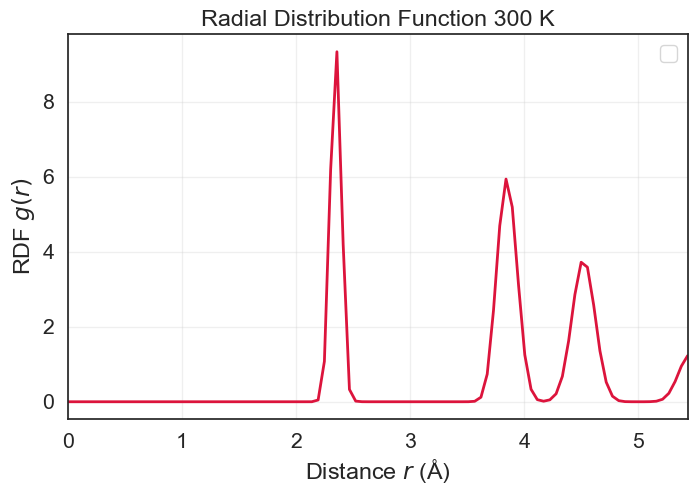

In [175]:
trajectory = read(output_dynamic_filename, index=":")
box_lengths = np.array([10.862, 10.862, 10.862])

nbins = 100
rmax = min(box_lengths) / 2.0
distances, avg_rdf_histogram = compute_rdf(trajectory, box_lengths, nbins=nbins, rmax=rmax)

plt.figure(figsize=(8, 5))
plt.plot(distances, avg_rdf_histogram, color='crimson', linewidth=2)
plt.xlabel('Distance $r$ (Å)')
plt.ylabel('RDF $g(r)$')
plt.title('Radial Distribution Function 300 K')
plt.xlim(0, rmax)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Initial Velocities are sampled from a Maxwell-Boltzmann distribution
kB = 1.380649e-23
amu_to_kg = 1.66053906660e-27
A_per_ps_to_m_per_s = 1e2

dt_3000= 2e-4
N_STEPS = 10000

temperature_desired = 3000.0  # K

sigma_m_s = np.sqrt(kB * temperature_desired / (atomic_mass_Si * amu_to_kg))
sigma_A_ps = sigma_m_s / A_per_ps_to_m_per_s

velocities_3000 = rng.normal(loc=0.0, scale=sigma_A_ps, size=(n_atoms, 3))

# remove center-of-mass drift
velocities_3000 -= velocities_3000.mean(axis=0, keepdims=True)

# rescale to match the target temperature exactly
velocities_m_s = velocities_3000 * A_per_ps_to_m_per_s
current_T = (atomic_mass_Si * amu_to_kg * np.mean(velocities_m_s**2)) / kB
velocities_3000 *= np.sqrt(temperature_desired / current_T)

positions_3000 = silicon_dataset[['x', 'y', 'z']].iloc[6000*n_atoms:6001*n_atoms].values.copy()

box_lengths_np = np.array([silicon_dataset['box_x'].iloc[0], 
                           silicon_dataset['box_y'].iloc[0], 
                           silicon_dataset['box_z'].iloc[0]])

output_dynamic_3000_filename = f"md_simulation_3000K.xyz"

mean_forces=[]

In [177]:
current_forces = compute_nn_forces(positions_3000)

trajectory_velocities_3000 = []

# Initialize the XYZ file
with open(output_dynamic_3000_filename, 'w') as f:
    pass 

for i in tqdm(range(N_STEPS), desc="Running MD Simulation"):
    
    # STEP 1: Update velocities by half a timestep (dt/2) using current forces
    accelerations = (current_forces / atomic_mass_Si) * FORCE_CONVERSION
    velocities_3000 += 0.5 * accelerations * dt_3000
    
    # STEP 2: Update positions by a full timestep (dt)
    positions_3000 += velocities_3000 * dt_3000
    
    # Apply Periodic Boundary Conditions (wrap positions back inside the simulation box)
    positions = positions_3000 % box_lengths_np
    
    # STEP 3: Compute NEW forces based on the updated positions
    current_forces = compute_nn_forces(positions)

    force_magnitudes = np.linalg.norm(current_forces, axis=1)
    max_force = np.max(force_magnitudes)
    mean_force_mag = np.mean(force_magnitudes)

    mean_forces.append(mean_force_mag)

    # STEP 4: Update velocities again by the remaining half timestep (dt/2)
    accelerations = (current_forces / atomic_mass_Si) * FORCE_CONVERSION
    velocities_3000 += 0.5 * accelerations * dt_3000
    
    trajectory_velocities_3000.append(velocities_3000.copy())
    
    # Log the trajectory (runs every 10 steps)
    if i % 10 == 0:
        with open(output_dynamic_3000_filename, 'a') as f:
            f.write(f"{n_atoms}\n")
            f.write(f"Step {i}\n")
            for atom_id in range(n_atoms):
                x, y, z = positions[atom_id]
                f.write(f"Si {x:.6f} {y:.6f} {z:.6f}\n")

trajectory_velocities_3000 = np.array(trajectory_velocities)

Running MD Simulation: 100%|██████████| 10000/10000 [03:04<00:00, 54.24it/s]


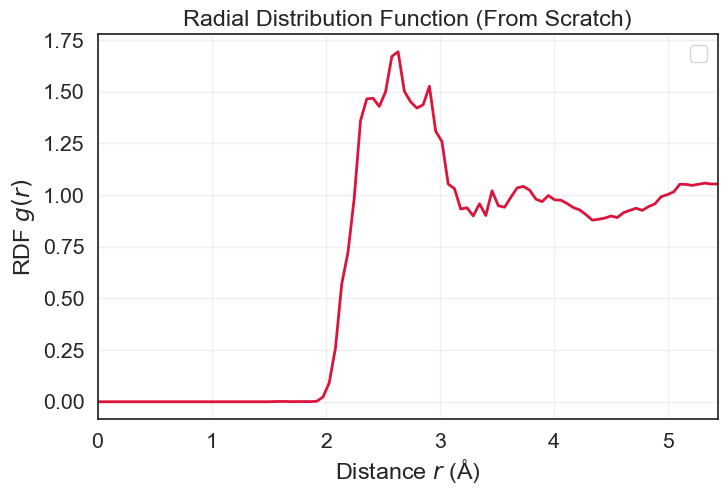

In [178]:
trajectory = read(output_dynamic_3000_filename, index=":")

box_lengths = np.array([10.862, 10.862, 10.862])

nbins = 100
rmax = min(box_lengths) / 2.0
distances, avg_rdf_histogram = compute_rdf(trajectory, box_lengths, nbins=nbins, rmax=rmax)

plt.figure(figsize=(8, 5))
plt.plot(distances, avg_rdf_histogram, color='crimson', linewidth=2)
plt.xlabel('Distance $r$ (Å)')
plt.ylabel('RDF $g(r)$')
plt.title('Radial Distribution Function (From Scratch)')
plt.xlim(0, rmax)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 🎵 Vibrational Density of States

The **Vibrational Density of States (VDOS)** is a powerful descriptor that provides a frequency-domain view of how the atoms in your system vibrate.

In a solid, atoms are not static; they oscillate around their equilibrium positions due to thermal energy. These vibrations occur at specific "normal mode" frequencies, which are dictated by the material's interatomic bonds and crystal structure.

* **Peaks:** Each peak in the VDOS represents a characteristic vibration frequency (or a range of frequencies) that is highly populated in the system.


* **Spectrum Shape:** The collection of these peaks acts as a spectroscopic "signature" of the material.


* **Material Fingerprint:** Like the RDF, the VDOS changes drastically between phases. A crystalline structure will exhibit sharp, well-defined peaks, whereas an amorphous or liquid phase will show a blurred, broader distribution due to the loss of long-range lattice periodicity.


We compute the VDOS by analyzing the temporal evolution of atomic velocities, following these steps:

1. **Velocity Autocorrelation Function (VACF):** We first calculate the VACF, which measures the correlation of the atoms' velocities with their own past values over time. 

$$VACF(\tau) = \frac{\langle \mathbf{v}_i(t+\tau) \cdot \mathbf{v}_i(t) \rangle}{\langle \mathbf{v}_i(t) \cdot \mathbf{v}_i(t) \rangle}$$


2. **Windowing:** Because our simulation trajectory is finite, we apply a window function (such as a Hanning window) to the VACF data to prevent "spectral leakage" during the transformation.


3. **Fourier Transform:** The VDOS is obtained by performing a Fourier Transform on the VACF.


4. **Power Spectrum:** We take the square of the magnitude of the FFT to obtain the power spectrum, which displays the distribution of vibrational energy across all possible frequencies.

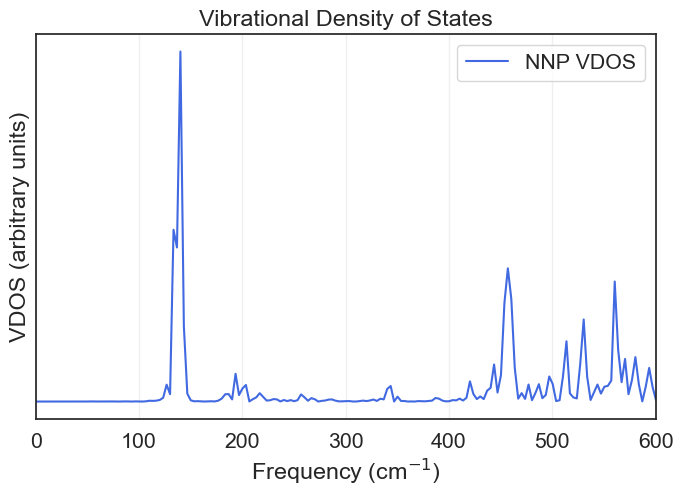

In [179]:
## VDOS is calculated as the Fourier transform of the Velocity Autocorrelation Function (VACF)

# trajectory_velocities shape: (n_frames, n_atoms, 3)
n_frames = trajectory_velocities.shape[0]
dt_ps = dt # Your timestep in picoseconds (e.g., 0.001)

# 1. Calculate VACF
vacf = np.zeros(n_frames)
# Denominator for normalization: <v(0) . v(0)>
v0_sq = np.sum(trajectory_velocities[0] * trajectory_velocities[0])

# We use the first frame as t=0 for simplicity. 
# For better statistics, you would average over multiple time origins.
for t in range(n_frames):
    dot_product = np.sum(trajectory_velocities[t] * trajectory_velocities[0])
    vacf[t] = dot_product / v0_sq

# 2. Apply a window function (optional but recommended)
# This reduces "leakage" in the Fourier transform caused by the finite length of the simulation
window = np.hanning(n_frames)
vacf_windowed = vacf * window

# 3. Fourier Transform to get VDOS
vdos = np.abs(fft(vacf_windowed))**2

# Get the corresponding frequencies
# dt_ps is in picoseconds, so frequencies will be in THz
frequencies_thz = fftfreq(n_frames, d=dt_ps)

# Convert THz to cm^-1 (common unit for vibrational spectra)
# 1 THz approx = 33.356 cm^-1
frequencies_cm1 = frequencies_thz * 33.35641

# Keep only the positive half of the spectrum
half_n = n_frames // 2
frequencies_cm1 = frequencies_cm1[:half_n]
vdos = vdos[:half_n]

# 4. Plot the result
plt.figure(figsize=(8, 5))
plt.plot(frequencies_cm1, vdos, label='NNP VDOS', color='royalblue')
# Usually we only plot up to ~600 cm^-1 for Silicon
plt.xlim(0, 600) 
plt.xlabel('Frequency (cm$^{-1}$)')
plt.ylabel('VDOS (arbitrary units)')
plt.title('Vibrational Density of States')
plt.yticks([]) # VDOS units are arbitrary, so we often hide the y-ticks
plt.legend()
plt.grid(alpha=0.3)
plt.show()